# OpenAlex Citation Gender Analysis
Inferred author gender, authorship composition, and citation impact across three subfields.

**Data**: fetched from OpenAlex via cursor pagination, or loaded from a local CSV (`USE_LOCAL_CSV`). Gender is inferred per author from given names, using WGND 2.0 as the primary signal and `gender_guesser` as a fallback.

**Corpora**:
1. Library and Information Sciences (subfield 3309)
2. Computer Graphics and Computer-Aided Design (subfield 1704)
3. Theoretical Computer Science (subfield 2614)


## 1. Setup

```bash
python3 -m venv venv && source venv/bin/activate   # venv\Scripts\activate on Windows
pip install requests pandas numpy matplotlib scipy pyarrow global_gender_predictor gender-guesser jupyter
```

Data is written to `./openalex_data/`: raw per-corpus `.jsonl.gz` archives plus the final Parquet output tables.

In [1]:
# Run once if the packages are not already installed.
!pip install -q requests pandas numpy matplotlib scipy pyarrow
!pip install -q global_gender_predictor gender-guesser


import sys
!{sys.executable} -m pip install gender-guesser global-gender-predictor


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\Khushi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\Khushi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and reproducibility

In [72]:
import os
import re
import gc
import gzip
import time
import json
import unicodedata
import textwrap
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

import gender_guesser.detector as gender_guesser_module
from global_gender_predictor import GlobalGenderPredictor

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_SEED = 202609
EXTRACTION_UTC = datetime.now(timezone.utc).isoformat()

# Set an integer here (e.g. 2000) to cap each corpus for a fast test run.
# Set to None to fetch every single matching work (the real, full run).
MAX_WORKS_PER_CORPUS = None

USE_LOCAL_CSV = True
LOCAL_CSV_PATH = Path("openalex_full_works.csv")  # already available

DATA_DIR = Path("openalex_data")
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = DATA_DIR / "output"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


#For plots
def wrap_text(text, width=28):
    """Wrap a long title/label onto multiple lines instead of letting it
    overflow or get silently truncated by the plotting backend."""
    return "\n".join(textwrap.wrap(str(text), width=width)) or str(text)

GENDER_COLORS = {
    "female": "#E75480",
    "male": "#1f77b4",
    "unknown": "#2ca02c",
}

CORPUS_PALETTE = ["#7570B3", "#E69F00", "#D55E00", "#999999", "#B8860B", "#8C564B"]

# Named explicitly since it's referenced by name a lot in this analysis.
PREFERRED_CORPUS_COLORS = {
    "Library and Information Sciences": "#7570B3",  # purple
}

def build_corpus_color_map(display_names):
    """One stable color per corpus, reused identically across every plot."""
    mapping = {}
    # exclude any color already claimed by a preferred assignment (e.g. LIS's
    # purple) from the cycling pool, so it can never get handed to a second,
    # unrelated corpus by coincidence
    reserved = set(PREFERRED_CORPUS_COLORS.values())
    available = [c for c in CORPUS_PALETTE if c not in reserved]
    palette_idx = 0
    for name in sorted(set(display_names)):
        if name in PREFERRED_CORPUS_COLORS:
            mapping[name] = PREFERRED_CORPUS_COLORS[name]
        else:
            mapping[name] = available[palette_idx % len(available)]
            palette_idx += 1
    return mapping

def label_stacked_bar_shares(ax, pivot, cols, counts=None):
    """Write a value label centered in each segment of a stacked bar chart.
    `counts`, if given, is a dict {(index_value, col): n} to show the raw
    count alongside the percentage; omit it for percentage-only labels.
    Segments smaller than 1.5% are skipped since there's no room to read them.
    """
    for i, idx_val in enumerate(pivot.index):
        bottom = 0
        for col in cols:
            share = pivot.loc[idx_val, col]
            if share > 0.015:
                pct = f"{share * 100:.1f}%"
                n = counts.get((idx_val, col)) if counts is not None else None
                text = f"{int(n)}\n({pct})" if n is not None else pct
                ax.text(i, bottom + share / 2, text, ha="center", va="center", fontsize=10)
            bottom += share

def label_bar_values(ax, fmt="{:.1%}"):
    """Write the value on top of every bar in a (non-stacked) bar chart."""
    for bar in ax.patches:
        height = bar.get_height()
        if np.isfinite(height):
            ax.annotate(
                fmt.format(height),
                (bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=10
            )

def reindex_to_full_years(df, year_col, value_cols):
    """Reindex a (year -> value) series/frame onto every calendar year in
    its own min..max range, filling gaps with NaN. This is what makes
    rolling-window smoothing correct: a `window=5` rolling mean should
    average 5 *calendar* years, not 5 rows -- and if a corpus/gender
    combination has no papers in some year, that year needs to exist as a
    real (NaN) gap, not be silently skipped, or "neighboring" points in
    the rolling window can actually be a decade apart.
    """
    full_years = np.arange(df[year_col].min(), df[year_col].max() + 1)
    out = df.set_index(year_col)[value_cols].reindex(full_years)
    return full_years, out

# Bigger fonts everywhere, set once so every plot in the notebook picks it up.
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
    "figure.titlesize": 19,
})

print("Extraction UTC:", EXTRACTION_UTC)
print("Data directory:", DATA_DIR.resolve())

Extraction UTC: 2026-09-14T09:55:55.946136+00:00
Data directory: D:\subtitles\openalex_data


## 3. OpenAlex API configuration

In [ ]:
OPENALEX_API_KEY = os.getenv("OPENALEX_API_KEY", "").strip()
OPENALEX_API_KEY = input("Enter your OpenAlex API key (or leave blank to run without one): ").strip()

BASE_URL = "https://api.openalex.org"

session = requests.Session()
session.headers.update({"User-Agent": "OpenAlex-gender-citation-prototype/2.0"})

def with_key(params=None):
    p = dict(params or {})
    if OPENALEX_API_KEY:
        p["api_key"] = OPENALEX_API_KEY
    return p

if not OPENALEX_API_KEY:
    print("No API key detected. Add one if OpenAlex rejects/limits the requests.")

## 4. Define the three corpora

In [74]:
CORPORA = {
    "subfield_3309": {
        "entity_type": "subfields",
        "entity_id": "3309",
        "filter": "primary_topic.subfield.id:3309",
    },
    "subfield_1704": {
        "entity_type": "subfields",
        "entity_id": "1704",
        "filter": "primary_topic.subfield.id:1704",
    },
    "subfield_2614": {
        "entity_type": "subfields",
        "entity_id": "2614",
        "filter": "primary_topic.subfield.id:2614",
    },
}

def get_entity_metadata(entity_type, entity_id):
    r = session.get(
        f"{BASE_URL}/{entity_type}/{entity_id}",
        params=with_key(),
        timeout=60
    )
    r.raise_for_status()
    return r.json()
#Display
for key, cfg in CORPORA.items():
    try:
        meta = get_entity_metadata(cfg["entity_type"], cfg["entity_id"])
        cfg["display_name"] = meta.get("display_name") or key
        cfg["works_count_openalex"] = meta.get("works_count")
    except Exception as e:
        print(f"  (skipping metadata lookup for {key}: {e})")
        cfg["display_name"] = key
        cfg["works_count_openalex"] = None
    print(key, "->", cfg["display_name"], "| works_count:", cfg["works_count_openalex"])

subfield_3309 -> Library and Information Sciences | works_count: 316751
subfield_1704 -> Computer Graphics and Computer-Aided Design | works_count: 262034
subfield_2614 -> Theoretical Computer Science | works_count: 281472


In [11]:
CORPUS_COLORS = build_corpus_color_map(cfg["display_name"] for cfg in CORPORA.values())

# For the combined (all-corpora-in-one) plots later: color already means
CORPUS_LINESTYLES_POOL = ["-", "--", ":", "-."]

def build_corpus_linestyle_map(display_names):
    names = sorted(set(display_names))
    return {name: CORPUS_LINESTYLES_POOL[i % len(CORPUS_LINESTYLES_POOL)] for i, name in enumerate(names)}

CORPUS_LINESTYLES = build_corpus_linestyle_map(cfg["display_name"] for cfg in CORPORA.values())

print("Corpus color map (used consistently in every multi-corpus plot below):")
for name, c in CORPUS_COLORS.items():
    print(f"  {name}: {c}  (line style in combined plots: {CORPUS_LINESTYLES[name]!r})")

Corpus color map (used consistently in every multi-corpus plot below):
  Computer Graphics and Computer-Aided Design: #E69F00  (line style in combined plots: '-')
  Library and Information Sciences: #7570B3  (line style in combined plots: '--')
  Theoretical Computer Science: #D55E00  (line style in combined plots: ':')


## 5. Get works per corpus

With `USE_LOCAL_CSV = True`, reads `LOCAL_CSV_PATH` and converts it into the same per-corpus `.jsonl.gz` files the API path produces, so everything downstream is identical either way. With `USE_LOCAL_CSV = False`, fetches from the API via cursor pagination (not subject to OpenAlex's 10,000-row offset-pagination cap), streaming each page directly to disk.

Use `MAX_WORKS_PER_CORPUS` in the config cell to cap this for a test run. If you re-run a fetch, delete the corresponding `.jsonl.gz` file first, or it will append a duplicate copy.

In [75]:
WORK_SELECT = ",".join([
    "id","doi","display_name","publication_year","publication_date","type",
    "cited_by_count","fwci","citation_normalized_percentile",
    "authorships","primary_topic","topics","keywords"
])

def csv_to_corpus_jsonl(csv_path, chunksize=50_000):
    """Convert the raw openalex_full_works.csv dump (one row per paper,
    JSON-stringified nested columns, a `corpus` column) back into the same
    per-corpus .jsonl.gz files the API-fetch path produces. One gzip file
    per corpus is kept open across chunks and written to incrementally, so
    this stays memory-safe even on a multi-GB CSV.
    """
    def parse_json(val):
        if val is None or (isinstance(val, float) and pd.isna(val)) or val in ("", "nan", "None"):
            return None
        try:
            return json.loads(val)
        except (json.JSONDecodeError, TypeError):
            return None

    def parse_int(val):
        try:
            return int(float(val))
        except (TypeError, ValueError):
            return None

    def parse_float(val):
        try:
            return float(val)
        except (TypeError, ValueError):
            return None

    open_files = {}
    counts = {}

    try:
        for chunk in pd.read_csv(csv_path, chunksize=chunksize, dtype=str, keep_default_na=False):
            # tolerate the print_name/display_name find-replace bug from an
            # earlier draft -- use whichever column is actually present
            title_col = "display_name" if "display_name" in chunk.columns else "print_name"

            for row in chunk.itertuples(index=False):
                row = row._asdict() if hasattr(row, "_asdict") else dict(zip(chunk.columns, row))
                corpus_key = row.get("corpus")
                if not corpus_key:
                    continue

                if corpus_key not in open_files:
                    out_path = RAW_DIR / f"{corpus_key}.jsonl.gz"
                    open_files[corpus_key] = gzip.open(out_path, "wt", encoding="utf-8")
                    counts[corpus_key] = 0
                    raw_paths[corpus_key] = out_path
                    # register any corpus present in the CSV but not already
                    # in CORPORA (e.g. if you changed the corpus set since
                    # generating this CSV)
                    if corpus_key not in CORPORA:
                        CORPORA[corpus_key] = {"display_name": corpus_key}

                work = {
                    "id": row.get("id") or None,
                    "doi": row.get("doi") or None,
                    "display_name": row.get(title_col) or None,
                    "publication_year": parse_int(row.get("publication_year")),
                    "publication_date": row.get("publication_date") or None,
                    "type": row.get("type") or None,
                    "cited_by_count": parse_int(row.get("cited_by_count")),
                    "fwci": parse_float(row.get("fwci")),
                    "citation_normalized_percentile": parse_json(row.get("citation_normalized_percentile")),
                    "authorships": parse_json(row.get("authorships")) or [],
                    "primary_topic": parse_json(row.get("primary_topic")),
                    "topics": parse_json(row.get("topics")),
                    "keywords": parse_json(row.get("keywords")),
                }
                open_files[corpus_key].write(json.dumps(work))
                open_files[corpus_key].write("\n")
                counts[corpus_key] += 1
    finally:
        for f in open_files.values():
            f.close()

    return counts

def fetch_all_works_to_disk(filter_string, out_path, per_page=200, max_retries=5,
                             sleep_between=0.1, max_works=None):
    """Stream every work matching `filter_string` straight to a gzip-
    compressed JSONL file on disk, one page at a time. Nothing is held in
    memory across pages -- this is the fix for the previous version
    keeping every corpus's full works list (with nested authorship/topic/
    keyword objects) in RAM simultaneously, which is what pushed a
    3-corpus full run past 16GB.
    """
    seen_ids = set()
    n_written = 0
    cursor = "*"
    page = 0

    with gzip.open(out_path, "wt", encoding="utf-8") as f:
        while cursor:
            params = with_key({
                "filter": filter_string,
                "per_page": per_page,
                "cursor": cursor,
                "select": WORK_SELECT,
            })

            for attempt in range(max_retries):
                r = session.get(f"{BASE_URL}/works", params=params, timeout=120)
                if r.status_code == 429:
                    wait = 2 ** attempt
                    print(f"  rate limited, waiting {wait}s...")
                    time.sleep(wait)
                    continue
                r.raise_for_status()
                break
            else:
                raise RuntimeError(f"Repeated 429s fetching page {page} of {filter_string!r}")

            payload = r.json()
            batch = payload.get("results", [])

            for w in batch:
                wid = w.get("id")
                if wid in seen_ids:
                    continue
                seen_ids.add(wid)
                f.write(json.dumps(w))
                f.write("\n")
                n_written += 1

            meta = payload.get("meta", {})
            cursor = meta.get("next_cursor")
            page += 1

            if page == 1:
                print(f"  OpenAlex reports {meta.get('count')} total matching works")
            if page % 20 == 0:
                print(f"  ...page {page}, {n_written} works written so far")

            if not batch:
                break
            if max_works is not None and n_written >= max_works:
                break

            time.sleep(sleep_between)

    return n_written

def stream_works(path):
    """Yield work dicts one at a time from a gzip JSONL file -- never
    loads the whole corpus into memory at once."""
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

raw_paths = {}

#if this json thing is avaialble dont compute it.

if USE_LOCAL_CSV:
    # Check whether we've already converted this CSV into per-corpus files
    # before re-running the (potentially slow, multi-GB) conversion.
    existing = sorted(RAW_DIR.glob("*.jsonl.gz"))
    if existing:
        print("Found existing converted corpus files, skipping CSV conversion:")
        for p in existing:
            key = p.stem.replace(".jsonl", "")  # strip .jsonl from "<key>.jsonl.gz" stem
            raw_paths[key] = p
            size_mb = p.stat().st_size / (1024 ** 2)
            print(f"  {key} -> {p} ({size_mb:.1f} MB compressed, already exists)")
    else:
        print(f"Converting local CSV: {LOCAL_CSV_PATH.resolve()}")
        counts = csv_to_corpus_jsonl(LOCAL_CSV_PATH)
        for key, n in counts.items():
            size_mb = raw_paths[key].stat().st_size / (1024 ** 2)
            print(key, f"-> wrote {n} works to {raw_paths[key]} ({size_mb:.1f} MB compressed)")
else:
    for key, cfg in CORPORA.items():
        out_path = RAW_DIR / f"{key}.jsonl.gz"
        if out_path.exists():
            raw_paths[key] = out_path
            size_mb = out_path.stat().st_size / (1024 ** 2)
            print(f"{key} -> already fetched at {out_path} ({size_mb:.1f} MB compressed), skipping API fetch")
            continue
        print(f"Fetching ALL works for: {key}  (filter: {cfg['filter']})")
        n = fetch_all_works_to_disk(cfg["filter"], out_path, max_works=MAX_WORKS_PER_CORPUS)
        raw_paths[key] = out_path
        size_mb = out_path.stat().st_size / (1024 ** 2)
        print(key, f"-> wrote {n} works to {out_path} ({size_mb:.1f} MB compressed)\n")

Found existing converted corpus files, skipping CSV conversion:
  subfield_1704 -> openalex_data\raw\subfield_1704.jsonl.gz (105.1 MB compressed, already exists)
  subfield_2614 -> openalex_data\raw\subfield_2614.jsonl.gz (54.8 MB compressed, already exists)
  subfield_3309 -> openalex_data\raw\subfield_3309.jsonl.gz (73.0 MB compressed, already exists)


## 6. Corpus overlap

Raw counts, % of row corpus, and Jaccard similarity between corpora.

In [76]:
def load_id_set(path):
    return {w["id"] for w in stream_works(path)}

work_sets = {k: load_id_set(p) for k, p in raw_paths.items()}

keys = list(work_sets)
overlap_counts = pd.DataFrame(index=keys, columns=keys, dtype=int)
overlap_pct_of_row = pd.DataFrame(index=keys, columns=keys, dtype=float)
overlap_jaccard = pd.DataFrame(index=keys, columns=keys, dtype=float)

for a in keys:
    for b in keys:
        inter = len(work_sets[a] & work_sets[b])
        union = len(work_sets[a] | work_sets[b])
        overlap_counts.loc[a, b] = inter
        overlap_pct_of_row.loc[a, b] = 100 * inter / len(work_sets[a]) if work_sets[a] else np.nan
        overlap_jaccard.loc[a, b] = inter / union if union else np.nan

print("Raw overlap counts (# works shared between corpora):")
display(overlap_counts)

print("\n% overlap, normalized by ROW corpus size")
print("(row=A, col=B -> what % of A's works are also in B; asymmetric when |A| != |B|):")
display(overlap_pct_of_row.round(1))

print("\nJaccard similarity (intersection / union) -- symmetric, size-invariant:")
display(overlap_jaccard.round(3))

memberships = sum(len(s) for s in work_sets.values())
unique_works = len(set().union(*work_sets.values()))
print("\nCorpus memberships:", memberships)
print("Unique works:", unique_works)
pct_shared = 100 * (memberships - unique_works) / memberships if memberships else 0
print(f"Overlap memberships: {memberships - unique_works} ({pct_shared:.1f}% of all memberships)")

Raw overlap counts (# works shared between corpora):


,subfield_1704,subfield_2614,subfield_3309
subfield_1704,220646.0,0.0,0.0
subfield_2614,0.0,196733.0,0.0
subfield_3309,0.0,0.0,266881.0



% overlap, normalized by ROW corpus size
(row=A, col=B -> what % of A's works are also in B; asymmetric when |A| != |B|):


,subfield_1704,subfield_2614,subfield_3309
subfield_1704,100.0,0.0,0.0
subfield_2614,0.0,100.0,0.0
subfield_3309,0.0,0.0,100.0



Jaccard similarity (intersection / union) -- symmetric, size-invariant:


,subfield_1704,subfield_2614,subfield_3309
subfield_1704,1.0,0.0,0.0
subfield_2614,0.0,1.0,0.0
subfield_3309,0.0,0.0,1.0



Corpus memberships: 684260
Unique works: 684260
Overlap memberships: 0 (0.0% of all memberships)


## 7. Gender inference

Primary signal: WGND 2.0 (`global_gender_predictor`), ~26M name-country records, applied with a confidence threshold. Fallback: `gender_guesser`, used only when WGND has no confident match. Each author's `gender_source` records which one actually produced the label.

`extract_given_name` treats `"Last, First Middle"` as a Western bibliographic name form and pulls the given name out accordingly.

In [77]:
wgnd_predictor = GlobalGenderPredictor()
legacy_detector = gender_guesser_module.Detector(case_sensitive=False)

WGND_THRESHOLD = 0.6  # matches predict_gender()'s own default; explicit here for clarity/tuning

def normalize_spaces(x):
    return re.sub(r"\s+", " ", (x or "").strip())

def strip_diacritics(x):
    x = unicodedata.normalize("NFKD", x or "")
    return "".join(c for c in x if not unicodedata.combining(c))

def extract_given_name(full_name):
    name = normalize_spaces(full_name)
    if not name:
        return None

    # Common Western bibliographic form: "Last, First Middle"
    if "," in name:
        _, right = name.split(",", 1)
        candidate_part = normalize_spaces(right)
    else:
        candidate_part = name

    if not candidate_part:
        return None

    token = candidate_part.split()[0]
    token = re.sub(
        r"^[^A-Za-z\u00C0-\u00D6\u00D8-\u00F6\u00F8-\u00FF\u0100-\u017E]+|"
        r"[^A-Za-z\u00C0-\u00D6\u00D8-\u00F6\u00F8-\u00FF\u0100-\u017E'\u2019-]+$",
        "",
        token
    )

    letters = re.sub(r"[^A-Za-z\u00C0-\u00D6\u00D8-\u00F6\u00F8-\u00FF\u0100-\u017E]", "", token)
    if len(letters) <= 1:
        return None

    return token or None

def infer_gender_from_name(full_name):
    """Returns (given_name, inferred_gender, raw_label, confidence, source).

    inferred_gender is one of 'female' / 'male' / 'unknown'.
    source is 'wgnd', 'gender_guesser_fallback', or 'none' (no usable name).
    """
    given = extract_given_name(full_name)
    if not given:
        return given, "unknown", "unusable_or_initial", None, "none"

    candidates = [given]
    stripped = strip_diacritics(given)
    if stripped and stripped != given:
        candidates.append(stripped)

    wgnd_label, wgnd_conf = "Unknown", 0.0
    for candidate in candidates:
        label, conf = wgnd_predictor.predict_gender_probability(candidate)
        if label != "Unknown":
            wgnd_label, wgnd_conf = label, conf
            break

    if wgnd_label != "Unknown" and wgnd_conf >= WGND_THRESHOLD:
        return given, wgnd_label.lower(), f"wgnd:{wgnd_label}:{wgnd_conf:.2f}", wgnd_conf, "wgnd"

    # WGND had nothing confident -- fall back to gender_guesser
    raw = "unknown"
    for candidate in candidates:
        raw = legacy_detector.get_gender(candidate)
        if raw != "unknown":
            break

    if raw in {"male", "mostly_male"}:
        inferred = "male"
    elif raw in {"female", "mostly_female"}:
        inferred = "female"
    else:
        inferred = "unknown"

    return given, inferred, raw, wgnd_conf, "gender_guesser_fallback"

for example in ["Thomas Mandl", "Khushi Pitroda", "Pitroda Khushi", "Aenne Knierim", "Katja Lapshinova"]:
    print(example, "->", infer_gender_from_name(example))

Thomas Mandl -> ('Thomas', 'male', 'wgnd:Male:1.00', 0.998, 'wgnd')
Khushi Pitroda -> ('Khushi', 'female', 'wgnd:Female:1.00', 1.0, 'wgnd')
Pitroda Khushi -> ('Pitroda', 'unknown', 'unknown', 0.0, 'gender_guesser_fallback')
Aenne Knierim -> ('Aenne', 'female', 'wgnd:Female:1.00', 1.0, 'wgnd')
Katja Lapshinova -> ('Katja', 'female', 'wgnd:Female:1.00', 1.0, 'wgnd')


## 8. Author-level and paper-level datasets

`authors_df`: one row per authorship. `papers_df`: one row per paper. First-author analysis uses OpenAlex's `author_position == "first"`.

In [78]:
def short_id(x):
    return None if not x else str(x).rstrip("/").split("/")[-1]

def optimize_dtypes(df, category_threshold=0.5):
    """Downcast object columns with low cardinality to `category` and
    shrink numeric dtypes -- cuts memory a lot on frames with a few
    corpora/genders/types repeated across hundreds of thousands of rows.
    """
    for col in df.select_dtypes(include="object").columns:
        n = len(df)
        if n and df[col].nunique(dropna=True) / n < category_threshold:
            df[col] = df[col].astype("category")
    for col in df.select_dtypes(include="int64").columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in df.select_dtypes(include="float64").columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    return df

author_rows = []
paper_rows = []

for corpus_key, path in raw_paths.items():
    corpus_name = CORPORA[corpus_key]["display_name"]

    for w in stream_works(path):
        work_id = short_id(w.get("id"))
        authorships = w.get("authorships") or []
        local_authors = []

        for a in authorships:
            author_obj = a.get("author") or {}
            author_name = (
                a.get("raw_author_name")
                or author_obj.get("display_name")
                or ""
            )

            given, inferred, raw_guess, confidence, source = infer_gender_from_name(author_name)

            row = {
                "corpus_key": corpus_key,
                "corpus_name": corpus_name,
                "work_id": work_id,
                "author_id": short_id(author_obj.get("id")),
                "author_name": author_name,
                "given_name_parsed": given,
                "gender_inferred": inferred,
                "gender_guesser_raw": raw_guess,
                "gender_confidence": confidence,
                "gender_source": source,
                "author_position": a.get("author_position"),
                "is_corresponding": a.get("is_corresponding"),
            }
            author_rows.append(row)
            local_authors.append(row)

        genders = [a["gender_inferred"] for a in local_authors]
        n_female = sum(g == "female" for g in genders)
        n_male = sum(g == "male" for g in genders)
        n_unknown = sum(g == "unknown" for g in genders)
        n_authors = len(local_authors)
        n_known_binary = n_female + n_male

        first_candidates = [
            a for a in local_authors
            if a["author_position"] == "first"
        ]
        first = first_candidates[0] if first_candidates else None

        pt = w.get("primary_topic") or {}
        sf = pt.get("subfield") or {}
        fld = pt.get("field") or {}
        dom = pt.get("domain") or {}
        cnp = w.get("citation_normalized_percentile") or {}

        paper_rows.append({
            "corpus_key": corpus_key,
            "corpus_name": corpus_name,
            "work_id": work_id,
            "doi": w.get("doi"),
            "title": w.get("display_name"),
            "publication_year": w.get("publication_year"),
            "publication_date": w.get("publication_date"),
            "work_type": w.get("type"),
            "cited_by_count": w.get("cited_by_count"),
            "fwci": w.get("fwci"),
            "citation_normalized_percentile": cnp.get("value"),
            "primary_topic_id": short_id(pt.get("id")),
            "primary_topic_name": pt.get("display_name"),
            "primary_subfield_id": short_id(sf.get("id")),
            "primary_subfield_name": sf.get("display_name"),
            "primary_field_id": short_id(fld.get("id")),
            "primary_field_name": fld.get("display_name"),
            "primary_domain_id": short_id(dom.get("id")),
            "primary_domain_name": dom.get("display_name"),
            "n_authors_openalex": n_authors,
            "n_inferred_female": n_female,
            "n_inferred_male": n_male,
            "n_unknown_gender": n_unknown,
            "n_binary_known_gender": n_known_binary,
            "female_author_share_inferred": (
                n_female / n_known_binary if n_known_binary else np.nan
            ),
            "male_author_share_inferred": (
                n_male / n_known_binary if n_known_binary else np.nan
            ),
            "unknown_author_share": (
                n_unknown / n_authors if n_authors else np.nan
            ),
            "first_author_id": first["author_id"] if first else None,
            "first_author_name": first["author_name"] if first else None,
            "first_author_given_name": first["given_name_parsed"] if first else None,
            "first_author_gender_inferred": (
                first["gender_inferred"] if first else "unknown"
            ),
            "first_author_gender_confidence": (
                first["gender_confidence"] if first else None
            ),
            "first_author_gender_source": (
                first["gender_source"] if first else "missing_first_authorship"
            ),
        })

authors_df = optimize_dtypes(pd.DataFrame(author_rows))
papers_df = optimize_dtypes(pd.DataFrame(paper_rows))

# free the list-of-dicts now that the (much more compact) DataFrames exist
del author_rows, paper_rows
gc.collect()

print("Authorship rows:", len(authors_df))
print("Paper/corpus rows:", len(papers_df))

C:\Users\Khushi\AppData\Local\Temp\ipykernel_28540\1015400179.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
C:\Users\Khushi\AppData\Local\Temp\ipykernel_28540\1015400179.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

Authorship rows: 1002578
Paper/corpus rows: 684260


In [79]:
# One row per unique author per corpus, aggregating across all of their
# papers *within that corpus*. This is what the Gini / representation-ratio
# / matched-comparison methods below need: they operate on researchers
# (total citations, total papers, career span), not on individual papers.
#
# Rows with no OpenAlex author_id (name-only authorships) can't be tracked
# as a consistent "researcher" across papers, so they're excluded here --
# they still count fully in the paper-level RQs above.
author_papers = authors_df.merge(
    papers_df[["corpus_key", "work_id", "cited_by_count", "fwci", "publication_year", "n_authors_openalex"]],
    on=["corpus_key", "work_id"],
    how="left"
)

author_level_df = (
    author_papers[author_papers["author_id"].notna()]
    .groupby(["corpus_key", "corpus_name", "author_id"])
    .agg(
        author_name=("author_name", "first"),
        gender_inferred=("gender_inferred", lambda s: s.mode().iat[0] if not s.mode().empty else "unknown"),
        n_papers=("work_id", "nunique"),
        total_citations=("cited_by_count", "sum"),
        mean_fwci=("fwci", "mean"),
        avg_coauthors_per_paper=("n_authors_openalex", "mean"),
        first_year=("publication_year", "min"),
        last_year=("publication_year", "max"),
    )
    .reset_index()
)
author_level_df["career_span_years"] = (
    author_level_df["last_year"] - author_level_df["first_year"] + 1
)
author_level_df = optimize_dtypes(author_level_df)

print("Unique tracked authors per corpus:")
display(author_level_df.groupby("corpus_name").size().rename("n_authors"))
author_level_df.head()

C:\Users\Khushi\AppData\Local\Temp\ipykernel_28540\1015400179.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Unique tracked authors per corpus:


corpus_name
Computer Graphics and Computer-Aided Design    245746
Library and Information Sciences               120291
Theoretical Computer Science                   129377
Name: n_authors, dtype: int64

,corpus_key,corpus_name,author_id,author_name,gender_inferred,n_papers,total_citations,mean_fwci,avg_coauthors_per_paper,first_year,last_year,career_span_years
0,subfield_1704,Computer Graphics and Computer-Aided Design,A5000000336,Jacek Wójcik,male,1,0,0.0000,3.00,2019.0,2019.0,1.0
1,subfield_1704,Computer Graphics and Computer-Aided Design,A5000000986,Franck Rochet,male,2,2,0.0000,13.75,2009.0,2010.0,2.0
2,subfield_1704,Computer Graphics and Computer-Aided Design,A5000001413,Kaoru Esaki,female,1,0,0.0000,9.00,2021.0,2021.0,1.0
3,subfield_1704,Computer Graphics and Computer-Aided Design,A5000001688,L. C. WOODS,unknown,1,0,0.0000,1.00,1958.0,1958.0,1.0
4,subfield_1704,Computer Graphics and Computer-Aided Design,A5000002144,Xiaokang Wei,unknown,2,1,1.0963,5.50,2025.0,2025.0,1.0


In [80]:
authors_df

,corpus_key,corpus_name,work_id,author_id,author_name,given_name_parsed,gender_inferred,gender_guesser_raw,gender_confidence,gender_source,author_position,is_corresponding
0,subfield_1704,Computer Graphics and Computer-Aided Design,W2229412420,A5068438875,William E. Lorensen,William,male,wgnd:Male:1.00,0.997,wgnd,first,False
1,subfield_1704,Computer Graphics and Computer-Aided Design,W2229412420,A5109058443,Harvey E. Cline,Harvey,male,wgnd:Male:1.00,0.996,wgnd,last,False
2,subfield_1704,Computer Graphics and Computer-Aided Design,W4233857083,A5068438875,William E. Lorensen,William,male,wgnd:Male:1.00,0.997,wgnd,first,False
3,subfield_1704,Computer Graphics and Computer-Aided Design,W4233857083,A5109058443,Harvey E. Cline,Harvey,male,wgnd:Male:1.00,0.996,wgnd,last,False
4,subfield_1704,Computer Graphics and Computer-Aided Design,W2112311198,A5037121552,Christophe Geuzaine,Christophe,male,wgnd:Male:1.00,1.000,wgnd,first,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1002573,subfield_3309,Library and Information Sciences,W99970159,A5009073878,LaVonne Hayes Sanborn,LaVonne,female,wgnd:Female:0.99,0.987,wgnd,first,True
1002574,subfield_3309,Library and Information Sciences,W99973003,A5103343940,Kathleen A. Hanna,Kathleen,female,wgnd:Female:1.00,0.998,wgnd,first,False
1002575,subfield_3309,Library and Information Sciences,W99973003,A5030727103,Mindy M. Cooper,Mindy,female,wgnd:Female:1.00,0.998,wgnd,middle,False
1002576,subfield_3309,Library and Information Sciences,W99973003,A5019369549,Robin A. Crumrin,Robin,male,wgnd:Male:0.70,0.702,wgnd,last,False


In [81]:
papers_df

,corpus_key,corpus_name,work_id,doi,title,publication_year,publication_date,work_type,cited_by_count,fwci,citation_normalized_percentile,primary_topic_id,primary_topic_name,primary_subfield_id,primary_subfield_name,primary_field_id,primary_field_name,primary_domain_id,primary_domain_name,n_authors_openalex,n_inferred_female,n_inferred_male,n_unknown_gender,n_binary_known_gender,female_author_share_inferred,male_author_share_inferred,unknown_author_share,first_author_id,first_author_name,first_author_given_name,first_author_gender_inferred,first_author_gender_confidence,first_author_gender_source
0,subfield_1704,Computer Graphics and Computer-Aided Design,W2229412420,https://doi.org/10.1145/37401.37422,Marching cubes: A high resolution 3D surface c...,1987.0,1987-08-01,conference-paper,10218,12.744200,1.000000,T10481,Computer Graphics and Visualization Techniques,1704,Computer Graphics and Computer-Aided Design,17,Computer Science,3,Physical Sciences,2,0,2,0,2,0.000000,1.000000,0.0,A5068438875,William E. Lorensen,William,male,0.997,wgnd
1,subfield_1704,Computer Graphics and Computer-Aided Design,W4233857083,https://doi.org/10.1145/37402.37422,Marching cubes: A high resolution 3D surface c...,1987.0,1987-08-01,article,8623,28.132200,1.000000,T10481,Computer Graphics and Visualization Techniques,1704,Computer Graphics and Computer-Aided Design,17,Computer Science,3,Physical Sciences,2,0,2,0,2,0.000000,1.000000,0.0,A5068438875,William E. Lorensen,William,male,0.997,wgnd
2,subfield_1704,Computer Graphics and Computer-Aided Design,W2112311198,https://doi.org/10.1002/nme.2579,Gmsh: A 3‐D finite element mesh generator with...,2009.0,2009-05-07,article,7772,312.826996,1.000000,T10996,Computational Geometry and Mesh Generation,1704,Computer Graphics and Computer-Aided Design,17,Computer Science,3,Physical Sciences,2,0,1,1,1,0.000000,1.000000,0.5,A5037121552,Christophe Geuzaine,Christophe,male,1.000,wgnd
3,subfield_1704,Computer Graphics and Computer-Aided Design,W4200150166,https://doi.org/10.1145/3503250,NeRF,2021.0,2021-12-17,article,6520,967.598206,1.000000,T10481,Computer Graphics and Visualization Techniques,1704,Computer Graphics and Computer-Aided Design,17,Computer Science,3,Physical Sciences,6,0,6,0,6,0.000000,1.000000,0.0,A5083849742,Ben Mildenhall,Ben,male,0.998,wgnd
4,subfield_1704,Computer Graphics and Computer-Aided Design,W1528027857,https://doi.org/10.15358/9783800648108,The Design of Everyday Things,2016.0,2016-01-01,book,6402,67.984398,1.000000,T14254,Digital Media and Visual Art,1704,Computer Graphics and Computer-Aided Design,17,Computer Science,3,Physical Sciences,1,0,1,0,1,0.000000,1.000000,0.0,A5031920284,Don Norman,Don,male,0.993,wgnd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684255,subfield_3309,Library and Information Sciences,W999572718,NaN,LibGuides: Library Faculty Council: Appendix I...,2014.0,2014-04-12,libguides,0,NaN,NaN,T10712,Library Science and Information Literacy,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,1,0,0,1,1.000000,0.000000,0.0,A5066621966,Kellie Sparks,Kellie,female,0.994,wgnd
684256,subfield_3309,Library and Information Sciences,W999689448,NaN,Library Website. Subject Guide: History. Prima...,2009.0,2009-06-12,article,0,0.000000,0.103383,T12289,Library Science and Administration,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,0,1,0,1,0.000000,1.000000,0.0,A5015835087,Michael Hurley,Michael,male,0.997,wgnd
684257,subfield_3309,Library and Information Sciences,W99970159,NaN,Reader's Theatre: A Library Media Specialist's...,1994.0,1994-01-01,article,0,0.000000,0.030130,T12289,Library Science and Administration,3309,Library and Information Sciences,33,Social Sciences,2,Social Sciences,1,1,0,0,1,1.000000,0.000000,0.0,A5009073878,LaVonne Hayes Sanborn,LaVonne,female,0.987,wgnd
684258,subfield_3309,Library and Information Sciences,W99973003,ht

## 9. Data-quality checks

Low-confidence/ambiguous names are retained as `unknown`, not dropped.

In [82]:
n_papers_per_corpus = papers_df.groupby("corpus_key").size().rename("n_papers_fetched")
print("Papers fetched per corpus (should roughly match works_count_openalex above,")
print("modulo MAX_WORKS_PER_CORPUS and any works missing authorship data):")
display(n_papers_per_corpus)

quality = papers_df.groupby(["corpus_key","corpus_name"]).agg(
    n_papers=("work_id","size"),
    missing_year=("publication_year", lambda s: s.isna().sum()),
    missing_citations=("cited_by_count", lambda s: s.isna().sum()),
    zero_authors=("n_authors_openalex", lambda s: (s == 0).sum()),
    unknown_first_author=(
        "first_author_gender_inferred",
        lambda s: (s == "unknown").sum()
    ),
    mean_unknown_author_share=("unknown_author_share","mean")
).reset_index()

display(quality)

print("Gender source breakdown (WGND vs gender_guesser fallback vs none):")
display(authors_df["gender_source"].value_counts(dropna=False).to_frame("n"))

print("\nRaw gender labels (post source-resolution):")
display(authors_df["gender_guesser_raw"].value_counts(dropna=False).to_frame("n"))

print("\nPotential 100-author capped works:")
display(
    papers_df.loc[
        papers_df["n_authors_openalex"] >= 100,
        ["corpus_name","work_id","title","n_authors_openalex"]
    ]
)

Papers fetched per corpus (should roughly match works_count_openalex above,
modulo MAX_WORKS_PER_CORPUS and any works missing authorship data):


corpus_key
subfield_1704    220646
subfield_2614    196733
subfield_3309    266881
Name: n_papers_fetched, dtype: int64

,corpus_key,corpus_name,n_papers,missing_year,missing_citations,zero_authors,unknown_first_author,mean_unknown_author_share
0,subfield_1704,Computer Graphics and Computer-Aided Design,220646,738,0,14070,80410,0.320212
1,subfield_2614,Theoretical Computer Science,196733,3804,0,30235,80288,0.301159
2,subfield_3309,Library and Information Sciences,266881,2075,0,13905,44432,0.121178


Gender source breakdown (WGND vs gender_guesser fallback vs none):


,n
gender_source,
wgnd,739038
gender_guesser_fallback,133672
none,129868



Raw gender labels (post source-resolution):


,n
gender_guesser_raw,
wgnd:Male:1.00,358324
wgnd:Female:1.00,206119
unusable_or_initial,129868
unknown,91329
wgnd:Male:0.99,35531
...,...
wgnd:Male:0.69,357
wgnd:Male:0.60,276
wgnd:Female:0.61,238



Potential 100-author capped works:


,corpus_name,work_id,title,n_authors_openalex
87565,Computer Graphics and Computer-Aided Design,W4405627589,Demonstrating dynamic surface codes,100
87644,Computer Graphics and Computer-Aided Design,W4415317034,Hunyuan3D Studio: End-to-End AI Pipeline for G...,100
172097,Computer Graphics and Computer-Aided Design,W4246508854,Elevated X-Maze,100
202943,Computer Graphics and Computer-Aided Design,W6928772144,Diffractive Photoproduction of J/ψ Mesons with...,100
205842,Computer Graphics and Computer-Aided Design,W7131066243,Euclid: Photometric redshift calibration perfo...,100
210839,Computer Graphics and Computer-Aided Design,W7160682202,Euclid preparation. Refining input galaxy shap...,100
213476,Computer Graphics and Computer-Aided Design,W7172559952,Slide Decks for Presentations,100
266231,Theoretical Computer Science,W4230544479,Area Under the Curve,100
266838,Theoretical Computer Science,W4240299002,Calouste Gulbenkian Foundation,100
331691,Theoretical Computer Science,W4206695238,LIST OF CONTRIBUTORS,100


## 10. Save

Saved as Parquet; falls back to CSV automatically if no parquet engine is importable.

In [83]:
def save_table(df, path_stub):
    """Parquet if an engine is importable, otherwise CSV -- pyarrow can hit
    the same Windows Application-Control DLL block statsmodels did, so this
    degrades gracefully instead of crashing the whole save step.
    """
    try:
        out_path = path_stub.with_suffix(".parquet")
        df.to_parquet(out_path, index=False)
        print("Saved", out_path)
    except ImportError as e:
        out_path = path_stub.with_suffix(".csv")
        print(f"  Parquet engine unavailable ({e.__class__.__name__}); falling back to CSV.")
        df.to_csv(out_path, index=False)
        print("Saved", out_path)

save_table(papers_df, OUTPUT_DIR / "openalex_per_corpus_papers")
save_table(authors_df, OUTPUT_DIR / "openalex_per_corpus_authors")
save_table(author_level_df, OUTPUT_DIR / "openalex_per_corpus_authors_aggregated")

print("Raw per-corpus archives (.jsonl.gz) remain in:", RAW_DIR.resolve())

  Parquet engine unavailable (ImportError); falling back to CSV.
Saved openalex_data\output\openalex_per_corpus_papers.csv
  Parquet engine unavailable (ImportError); falling back to CSV.
Saved openalex_data\output\openalex_per_corpus_authors.csv
  Parquet engine unavailable (ImportError); falling back to CSV.
Saved openalex_data\output\openalex_per_corpus_authors_aggregated.csv
Raw per-corpus archives (.jsonl.gz) remain in: D:\subtitles\openalex_data\raw


# RQ1: Author gender distribution
$$
\text{FemaleShare} =
\frac{N_{\text{inferred female}}}
{N_{\text{inferred female}} + N_{\text{inferred male}}}
$$

In [84]:
rq1_counts = (
    authors_df
    .groupby(["corpus_key","corpus_name","gender_inferred"])
    .size()
    .rename("n")
    .reset_index()
)

rq1_counts["share_all_authorships"] = (
    rq1_counts["n"]
    / rq1_counts.groupby("corpus_key")["n"].transform("sum")
)

rq1 = rq1_counts.pivot_table(
    index=["corpus_key","corpus_name"],
    columns="gender_inferred",
    values="n",
    fill_value=0
).reset_index()

for col in ["female","male","unknown"]:
    if col not in rq1:
        rq1[col] = 0

rq1["binary_classified_n"] = rq1["female"] + rq1["male"]
rq1["female_share_among_binary_classified"] = (
    rq1["female"] / rq1["binary_classified_n"].replace(0, np.nan)
)
rq1["unknown_share_all"] = (
    rq1["unknown"] /
    (rq1["female"] + rq1["male"] + rq1["unknown"])
)

display(rq1)

gender_inferred,corpus_key,corpus_name,female,male,unknown,binary_classified_n,female_share_among_binary_classified,unknown_share_all
0,subfield_1704,Computer Graphics and Computer-Aided Design,75396.0,232210.0,143920.0,307606.0,0.245106,0.318741
1,subfield_2614,Theoretical Computer Science,28859.0,132262.0,70356.0,161121.0,0.179114,0.303944
2,subfield_3309,Library and Information Sciences,176502.0,102268.0,40805.0,278770.0,0.633146,0.127685


In [85]:

rq1["total_authors"] = (
    rq1["female"] +
    rq1["male"] +
    rq1["unknown"]
)

rq1 = rq1.merge(
    papers_df.groupby("corpus_key").size().rename("n_papers"),
    left_on="corpus_key", right_index=True
)

rq1["avg_authors_per_paper"] = rq1["total_authors"] / rq1["n_papers"]

display(
    rq1[
        ["corpus_name", "n_papers", "total_authors", "avg_authors_per_paper"]
    ]
)

,corpus_name,n_papers,total_authors,avg_authors_per_paper
0,Computer Graphics and Computer-Aided Design,220646,451526.0,2.046382
1,Theoretical Computer Science,196733,231477.0,1.176605
2,Library and Information Sciences,266881,319575.0,1.197444


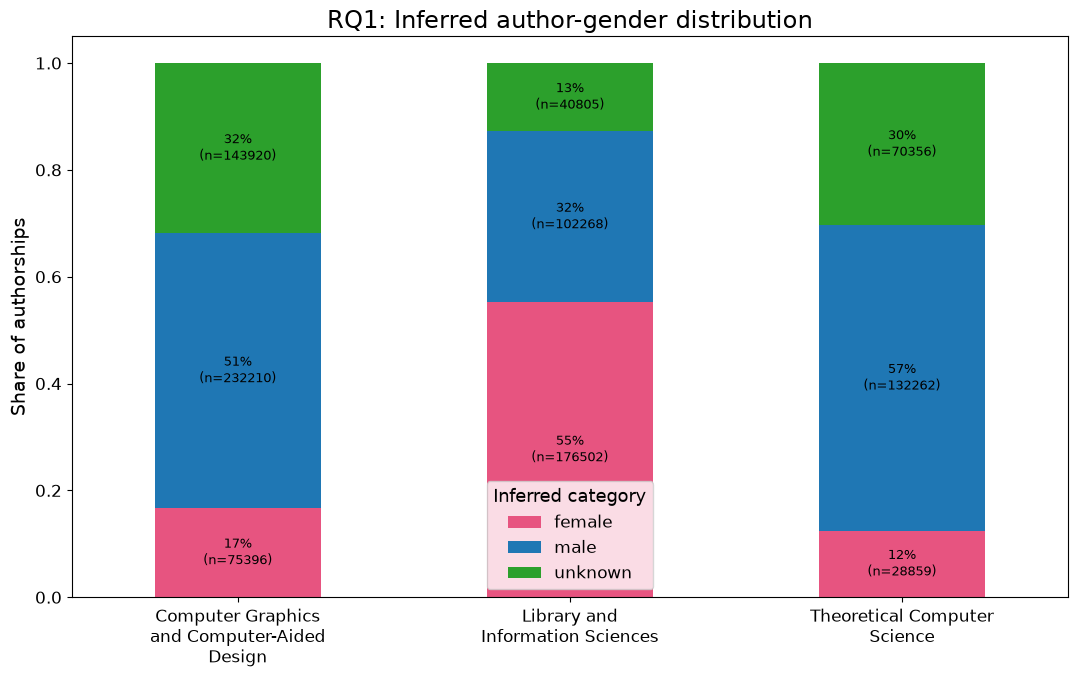

In [89]:
rq1_plot = rq1_counts.pivot_table(
    index="corpus_name",
    columns="gender_inferred",
    values="share_all_authorships",
    fill_value=0
)

cols = [c for c in ["female", "male", "unknown"] if c in rq1_plot.columns]
bar_colors = [GENDER_COLORS[c] for c in cols]

ax = rq1_plot[cols].plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7),
    color=bar_colors
)

ax.set_title(wrap_text("RQ1: Inferred author-gender distribution", 50))
ax.set_ylabel("Share of authorships")
ax.set_xlabel("")
ax.legend(title="Inferred category")

ax.set_xticklabels([wrap_text(name, 20) for name in rq1_plot.index], rotation=0)

counts_lookup = {(row.corpus_name, row.gender_inferred): row.n for row in rq1_counts.itertuples()}
label_stacked_bar_shares(ax, rq1_plot[cols], cols, counts=counts_lookup)

plt.tight_layout()
plt.show()

# RQ: Only-female / only-male / mixed-authored papers

Each paper is classified as **only_female** (every binary-known author is female), **only_male**, **mixed** (both present), or **no_known_gender** (no binary-known author at all).

,corpus_name,authorship_mix,n_papers,share_within_corpus
0,Computer Graphics and Computer-Aided Design,mixed,28615,0.129687
1,Computer Graphics and Computer-Aided Design,no_known_gender,64935,0.294295
2,Computer Graphics and Computer-Aided Design,only_female,31701,0.143674
3,Computer Graphics and Computer-Aided Design,only_male,95395,0.432344
4,Library and Information Sciences,mixed,15249,0.057138
5,Library and Information Sciences,no_known_gender,40925,0.153345
6,Library and Information Sciences,only_female,136384,0.511029
7,Library and Information Sciences,only_male,74323,0.278487
8,Theoretical Computer Science,mixed,7334,0.037279
9,Theoretical Computer Science,no_known_gender,76410,0.388394


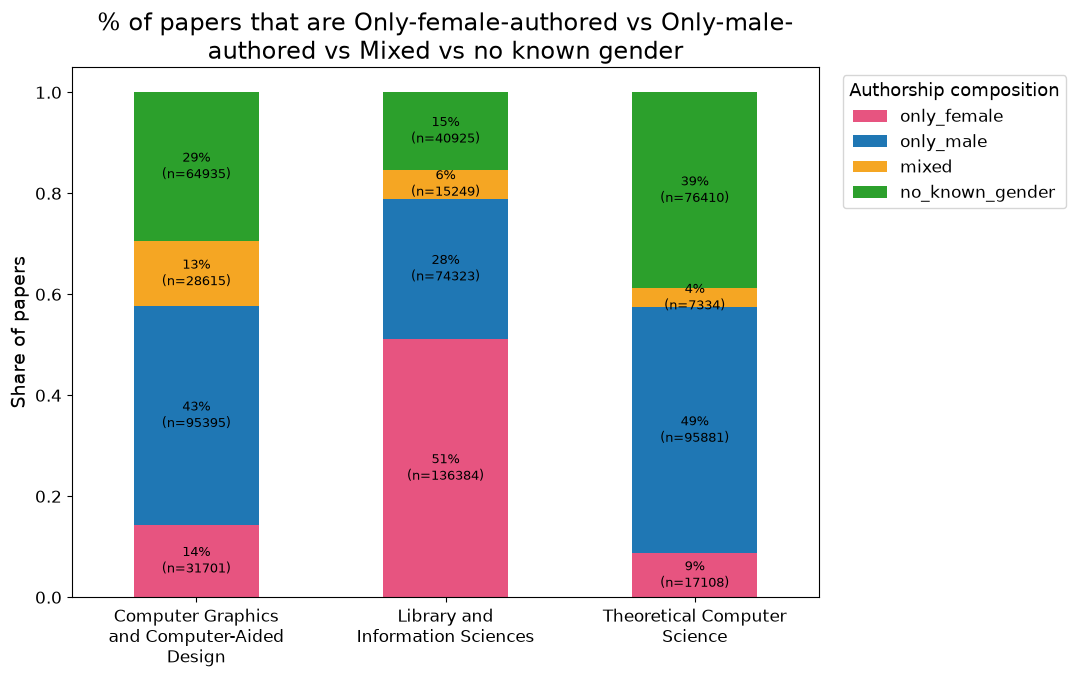

In [90]:
conditions = [
    papers_df["n_binary_known_gender"] == 0,
    (papers_df["n_inferred_female"] > 0) & (papers_df["n_inferred_male"] == 0),
    (papers_df["n_inferred_male"] > 0) & (papers_df["n_inferred_female"] == 0),
]
choices = ["no_known_gender", "only_female", "only_male"]
papers_df["authorship_mix"] = np.select(conditions, choices, default="mixed")

mix_counts = (
    papers_df
    .groupby(["corpus_name", "authorship_mix"])
    .size()
    .rename("n_papers")
    .reset_index()
)
mix_counts["share_within_corpus"] = (
    mix_counts["n_papers"] / mix_counts.groupby("corpus_name")["n_papers"].transform("sum")
)
display(mix_counts)

MIX_COLORS = {
    "only_female": GENDER_COLORS["female"],
    "only_male": GENDER_COLORS["male"],
    "mixed": "#F5A623",          # distinct amber -- not a gender color, not a corpus color
    "no_known_gender": GENDER_COLORS["unknown"],
}
mix_order = ["only_female", "only_male", "mixed", "no_known_gender"]

pivot = mix_counts.pivot_table(
    index="corpus_name", columns="authorship_mix", values="share_within_corpus", fill_value=0
)
pivot = pivot[[c for c in mix_order if c in pivot.columns]]
bar_colors = [MIX_COLORS[c] for c in pivot.columns]

ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 7), color=bar_colors)
ax.set_title(wrap_text(
    "% of papers that are Only-female-authored vs Only-male-authored vs Mixed vs no known gender", 55
))
ax.set_ylabel("Share of papers")
ax.set_xlabel("")
ax.set_xticklabels([wrap_text(t.get_text(), 20) for t in ax.get_xticklabels()], rotation=0)
counts_lookup = {(row.corpus_name, row.authorship_mix): row.n_papers for row in mix_counts.itertuples()}
label_stacked_bar_shares(ax, pivot, pivot.columns.tolist(), counts=counts_lookup)

ax.legend(title="Authorship composition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# First-author gender comparison

,corpus_key,corpus_name,first_author_gender_inferred,n_papers,share_within_corpus
0,subfield_1704,Computer Graphics and Computer-Aided Design,female,39863,0.180665
1,subfield_1704,Computer Graphics and Computer-Aided Design,male,100373,0.454905
2,subfield_1704,Computer Graphics and Computer-Aided Design,unknown,80410,0.364430
3,subfield_2614,Theoretical Computer Science,female,19424,0.098733
4,subfield_2614,Theoretical Computer Science,male,97021,0.493161
5,subfield_2614,Theoretical Computer Science,unknown,80288,0.408106
6,subfield_3309,Library and Information Sciences,female,142691,0.534662
7,subfield_3309,Library and Information Sciences,male,79758,0.298852
8,subfield_3309,Library and Information Sciences,unknown,44432,0.166486


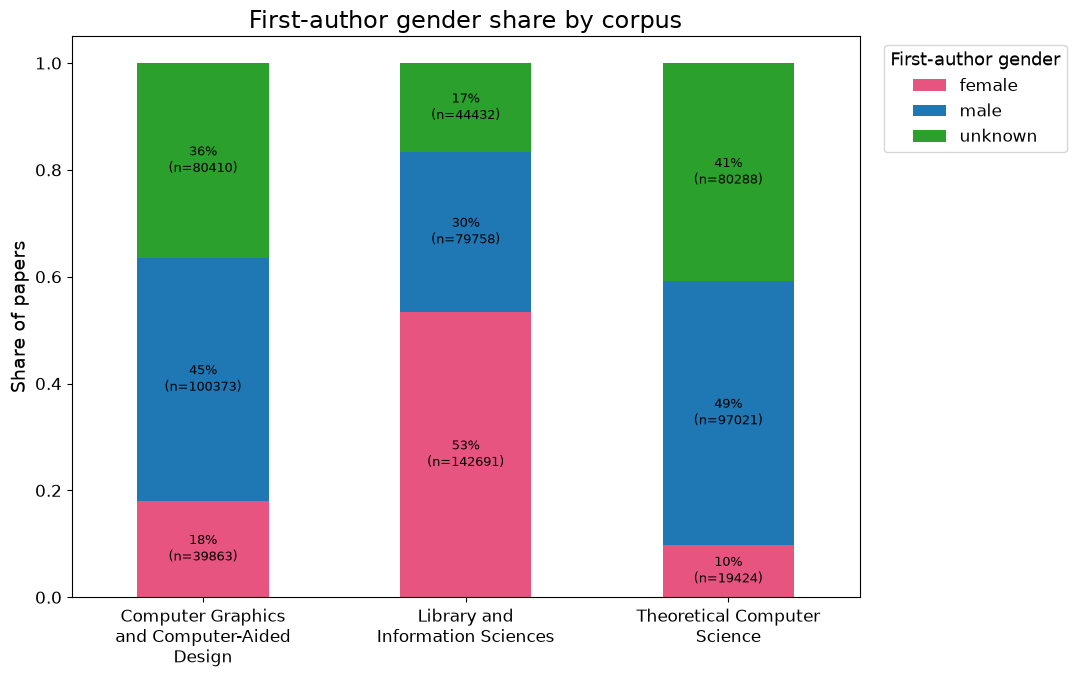

In [91]:
rq1_first = (
    papers_df
    .groupby(["corpus_key","corpus_name","first_author_gender_inferred"])
    .size()
    .rename("n_papers")
    .reset_index()
)

rq1_first["share_within_corpus"] = (
    rq1_first["n_papers"]
    / rq1_first.groupby("corpus_key")["n_papers"].transform("sum")
)

display(rq1_first)


def wrap_text(text, width=20):
    return "\n".join(textwrap.wrap(str(text), width))

def label_stacked_bar_shares(ax, pivot, columns, counts=None, min_share=0.03):
    """Label each stacked segment with its % (and n, if counts provided)."""
    for bar_idx, corpus in enumerate(pivot.index):
        bottom = 0
        for col in columns:
            share = pivot.loc[corpus, col]
            if share < min_share:
                bottom += share
                continue
            y = bottom + share / 2
            label = f"{share:.0%}"
            if counts is not None:
                n = counts.get((corpus, col))
                if n is not None:
                    label += f"\n(n={n})"
            ax.text(bar_idx, y, label, ha="center", va="center", fontsize=9)
            bottom += share

GENDER_ORDER = ["female", "male", "unknown"]  # adjust to your actual category names
bar_colors = [GENDER_COLORS[c] for c in GENDER_ORDER]

pivot = rq1_first.pivot_table(
    index="corpus_name",
    columns="first_author_gender_inferred",
    values="share_within_corpus",
    fill_value=0
)
pivot = pivot[[c for c in GENDER_ORDER if c in pivot.columns]]

ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 7), color=bar_colors[:len(pivot.columns)])
ax.set_title(wrap_text("First-author gender share by corpus", 55))
ax.set_ylabel("Share of papers")
ax.set_xlabel("")
ax.set_xticklabels([wrap_text(t.get_text(), 20) for t in ax.get_xticklabels()], rotation=0)

counts_lookup = {
    (row.corpus_name, row.first_author_gender_inferred): row.n_papers
    for row in rq1_first.itertuples()
}
label_stacked_bar_shares(ax, pivot, pivot.columns.tolist(), counts=counts_lookup)

ax.legend(title="First-author gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [92]:
def style_axis(ax, grid_axis="y"):
    """Shared look for the charts below: no top/right spines, a soft grid,
    and value labels doing the work instead of chart chrome."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#999999")
    ax.spines["bottom"].set_color("#999999")
    if grid_axis:
        ax.grid(axis=grid_axis, color="#e2e2e2", linewidth=0.9, zorder=0)
        ax.set_axisbelow(True)

# RQ2: Citation comparison by gender composition
$$
\text{FemaleShare}_i =
\frac{F_i}{F_i + M_i}
$$

In [35]:
rq2_df = papers_df[
    papers_df["female_author_share_inferred"].notna()
    & papers_df["cited_by_count"].notna()
    & papers_df["publication_year"].notna()
    & (papers_df["n_authors_openalex"] > 0)
].copy()

rq2_df["log1p_citations"] = np.log1p(rq2_df["cited_by_count"])

diagnostics = rq2_df.groupby("corpus_name")["cited_by_count"].agg(
    n="size",
    mean="mean",
    median="median",
    variance="var",
    minimum="min",
    maximum="max"
).reset_index()

diagnostics["variance_to_mean"] = (
    diagnostics["variance"] /
    diagnostics["mean"].replace(0, np.nan)
)

display(diagnostics)

,corpus_name,n,mean,median,variance,minimum,maximum,variance_to_mean
0,Computer Graphics and Computer-Aided Design,155471,9.392002,0.0,5833.359931,0,10218,621.098644
1,Library and Information Sciences,224967,1.798966,0.0,156.346933,0,1493,86.909328
2,Theoretical Computer Science,118011,5.110778,0.0,3769.489186,0,9153,737.556851


With full corpora this can be tens of thousands of points, so `female_author_share_inferred` is binned into deciles. The plot shows mean log-citations ± 95% CI per bin, with each bin's sample size `n` annotated.

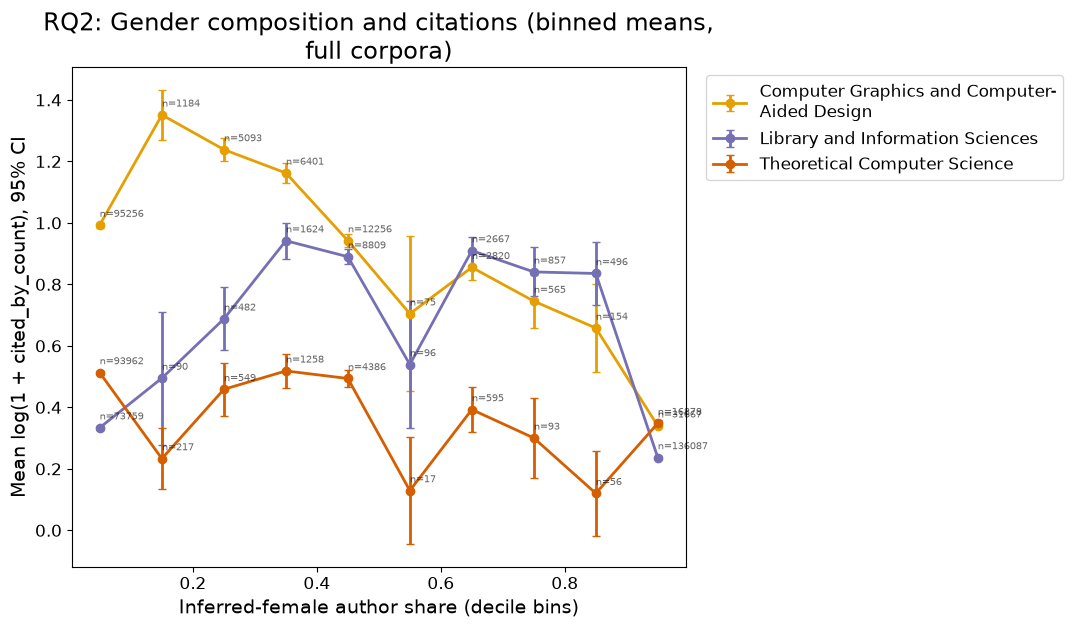

In [36]:
BIN_EDGES = np.linspace(0, 1, 11)  # deciles: 0-0.1, 0.1-0.2, ... 0.9-1.0
rq2_df["female_share_bin"] = pd.cut(
    rq2_df["female_author_share_inferred"], BIN_EDGES, include_lowest=True
)

binned = (
    rq2_df
    .groupby(["corpus_name", "female_share_bin"], observed=True)["log1p_citations"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
binned["se"] = binned["std"] / np.sqrt(binned["count"])
binned["ci95"] = 1.96 * binned["se"]
binned["bin_mid"] = binned["female_share_bin"].apply(lambda iv: iv.mid).astype(float)

fig, ax = plt.subplots(figsize=(11, 6.5))

for corpus_name, g in binned.groupby("corpus_name"):
    g = g.sort_values("bin_mid")
    ax.errorbar(
        g["bin_mid"], g["mean"], yerr=g["ci95"],
        marker="o", capsize=3, color=CORPUS_COLORS.get(corpus_name),
        linewidth=2, label=wrap_text(corpus_name, 32)
    )
    for _, row in g.iterrows():
        if pd.notna(row["mean"]):
            ax.annotate(
                f"n={int(row['count'])}",
                (row["bin_mid"], row["mean"]),
                fontsize=7, alpha=0.6,
                textcoords="offset points", xytext=(0, 6)
            )

ax.set_xlabel("Inferred-female author share (decile bins)")
ax.set_ylabel("Mean log(1 + cited_by_count), 95% CI")
ax.set_title(wrap_text("RQ2: Gender composition and citations (binned means, full corpora)", 55))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Citation share.** Each paper's citations are split proportionally to its female-author share and summed across the corpus: `sum(female-attributed citations) / sum(all citations)`. This is the fraction of all citations attributable to female authors, comparable directly against their participation share.

,corpus_name,female_first_author_share,male_first_author_share,female_citation_share,male_citation_share
0,Computer Graphics and Computer-Aided Design,0.284257,0.715743,0.096567,0.903433
1,Library and Information Sciences,0.641455,0.358545,0.553043,0.446957
2,Theoretical Computer Science,0.166808,0.833192,0.086829,0.913171


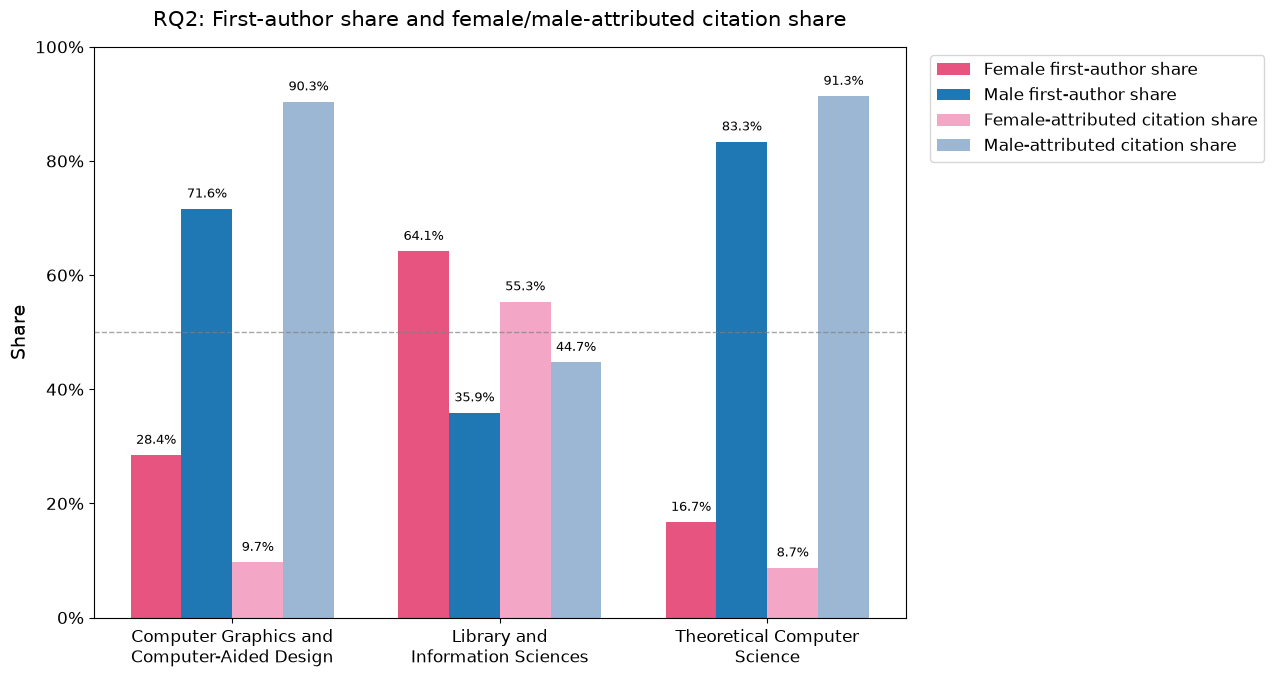

In [106]:
import matplotlib.ticker

rq2_compare = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female", "male"])
    & papers_df["cited_by_count"].notna()
].copy()

# First-author shares
first_author_counts = (
    rq2_compare.groupby(["corpus_name", "first_author_gender_inferred"])
    .size().rename("n_papers").reset_index()
)
first_author_counts["first_author_share"] = (
    first_author_counts["n_papers"]
    / first_author_counts.groupby("corpus_name")["n_papers"].transform("sum")
)

# Fractional citation attribution
rq2_compare["female_citations"] = (
    rq2_compare["cited_by_count"] * rq2_compare["female_author_share_inferred"]
)
rq2_compare["male_citations"] = (
    rq2_compare["cited_by_count"] * rq2_compare["male_author_share_inferred"]
)

citation_summary = (
    rq2_compare.groupby("corpus_name")
    .agg(
        total_citations=("cited_by_count", "sum"),
        female_citations=("female_citations", "sum"),
        male_citations=("male_citations", "sum")
    ).reset_index()
)

citation_summary["female_citation_share"] = (
    citation_summary["female_citations"] / citation_summary["total_citations"]
)
citation_summary["male_citation_share"] = (
    citation_summary["male_citations"] / citation_summary["total_citations"]
)

comparison = (
    first_author_counts
    .pivot(
        index="corpus_name",
        columns="first_author_gender_inferred",
        values="first_author_share"
    )
    .rename(columns={
        "female": "female_first_author_share",
        "male": "male_first_author_share"
    })
    .reset_index()
    .merge(
        citation_summary[
            ["corpus_name", "female_citation_share", "male_citation_share"]
        ],
        on="corpus_name", how="left"
    )
)

display(comparison)

# Plot
plot_df = comparison.set_index("corpus_name")[
    ["female_first_author_share", "male_first_author_share",
     "female_citation_share", "male_citation_share"]
]

fig, ax = plt.subplots(figsize=(13, 7))
x, width = np.arange(len(plot_df)), 0.19

bars = [
    ax.bar(x - 1.5*width, plot_df["female_first_author_share"], width,
           color=GENDER_COLORS["female"], label="Female first-author share"),
    ax.bar(x - 0.5*width, plot_df["male_first_author_share"], width,
           color=GENDER_COLORS["male"], label="Male first-author share"),
    ax.bar(x + 0.5*width, plot_df["female_citation_share"], width,
           color="#F4A6C6", label="Female-attributed citation share"),
    ax.bar(x + 1.5*width, plot_df["male_citation_share"], width,
           color="#9BB7D4", label="Male-attributed citation share")
]

for group in bars:
    for bar in group:
        v = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2, v + 0.015,
            f"{v:.1%}", ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels([wrap_text(n, 22) for n in plot_df.index])
ax.set_ylabel("Share")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.axhline(0.5, linestyle="--", linewidth=1, color="gray", alpha=0.7)
ax.set_title(
    wrap_text(
        "RQ2: First-author share and female/male-attributed citation share", 65
    ),
    fontsize=15, pad=15
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

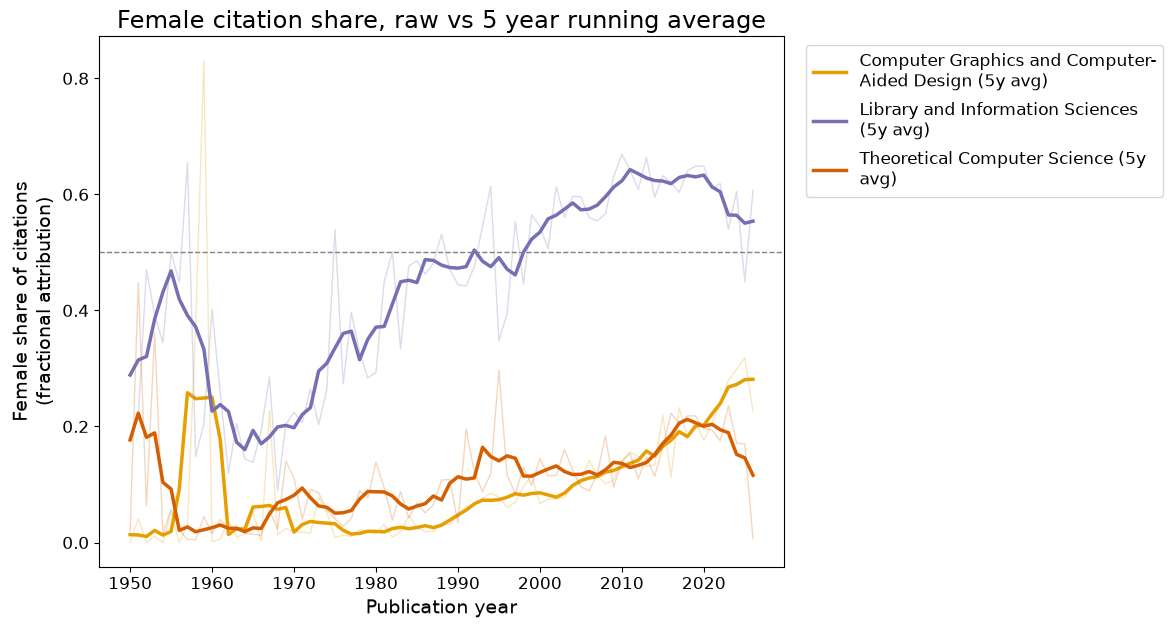

In [107]:
# Reuses MIN_PLAUSIBLE_YEAR from the RQ5 cell if you've already run it;
# falls back to the same default here so this cell also works standalone.
MIN_PLAUSIBLE_YEAR = globals().get("MIN_PLAUSIBLE_YEAR", 1950)
rq2_df_plausible_years = rq2_df[rq2_df["publication_year"] >= MIN_PLAUSIBLE_YEAR]

rq2_yearly = (
    rq2_df_plausible_years.groupby(["corpus_name", "publication_year"])
    .agg(
        total_citations=("cited_by_count", "sum"),
        total_citations_to_female=("citations_to_female", "sum"),
    )
    .reset_index()
    .sort_values(["corpus_name", "publication_year"])
)
rq2_yearly["female_citation_share"] = (
    rq2_yearly["total_citations_to_female"] / rq2_yearly["total_citations"].replace(0, np.nan)
)

ROLLING_WINDOW_YEARS = 5  # bumped up from 3 for a visibly smoother trend line

fig, ax = plt.subplots(figsize=(12, 6.5))
for corpus_name, g in rq2_yearly.groupby("corpus_name"):
    g = g.sort_values("publication_year")
    # Reindex onto every calendar year in range first, THEN roll -- rolling
    # over the raw rows (as before) silently treats years with a gap as
    # "adjacent", which is why the smoothing didn't look smooth.
    full_years, s = reindex_to_full_years(g, "publication_year", ["female_citation_share"])
    s = s["female_citation_share"]
    rolling = s.rolling(ROLLING_WINDOW_YEARS, min_periods=1, center=True).mean()

    color = CORPUS_COLORS.get(corpus_name)
    ax.plot(full_years, s, alpha=0.25, linewidth=1, color=color)
    ax.plot(full_years, rolling, linewidth=2.5, color=color,
            label=wrap_text(f"{corpus_name} ({ROLLING_WINDOW_YEARS}y avg)", 32))

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Publication year")
ax.set_ylabel("Female share of citations\n(fractional attribution)")
ax.set_title(wrap_text(f"Female citation share, raw vs {ROLLING_WINDOW_YEARS} year running average", 60))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# RQ3: Citation comparison by first-author gender

Reports descriptive statistics, a Mann-Whitney U test per corpus, and the same comparison using FWCI (field- and year-normalized citation impact) alongside raw citation counts. Unknown first authors are excluded from this binary comparison, though they're retained everywhere else in the notebook.

In [108]:
rq3_df = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female","male"])
    & papers_df["cited_by_count"].notna()
    & papers_df["publication_year"].notna()
].copy()

rq3_summary = rq3_df.groupby(
    ["corpus_name","first_author_gender_inferred"]
)["cited_by_count"].agg(
    n="size",
    mean="mean",
    median="median",
    std="std",
    minimum="min",
    maximum="max"
).reset_index()

display(rq3_summary)

,corpus_name,first_author_gender_inferred,n,mean,median,std,minimum,maximum
0,Computer Graphics and Computer-Aided Design,female,39821,3.456920,0.0,26.355826,0,1753
1,Computer Graphics and Computer-Aided Design,male,100211,11.886270,0.0,90.354241,0,10218
2,Library and Information Sciences,female,142361,1.528874,0.0,10.170036,0,1005
3,Library and Information Sciences,male,79158,2.200725,0.0,15.781090,0,1493
4,Theoretical Computer Science,female,19174,2.575675,0.0,25.358616,0,1847
5,Theoretical Computer Science,male,95069,5.489581,0.0,64.665386,0,9153


In [109]:
rq3_mw = []

for corpus_name, g in rq3_df.groupby("corpus_name"):
    female = g.loc[
        g["first_author_gender_inferred"] == "female",
        "cited_by_count"
    ].dropna()

    male = g.loc[
        g["first_author_gender_inferred"] == "male",
        "cited_by_count"
    ].dropna()

    if len(female) and len(male):
        u, p = stats.mannwhitneyu(
            female,
            male,
            alternative="two-sided",
            method="auto"
        )
    else:
        u, p = np.nan, np.nan

    rq3_mw.append({
        "corpus_name": corpus_name,
        "n_female_first": len(female),
        "n_male_first": len(male),
        "median_citations_female_first": female.median() if len(female) else np.nan,
        "median_citations_male_first": male.median() if len(male) else np.nan,
        "mann_whitney_U": u,
        "p_value": p
    })

rq3_mw = pd.DataFrame(rq3_mw)
display(rq3_mw)

,corpus_name,n_female_first,n_male_first,median_citations_female_first,median_citations_male_first,mann_whitney_U,p_value
0,Computer Graphics and Computer-Aided Design,39821,100211,0.0,0.0,1.587456e+09,0.000000e+00
1,Library and Information Sciences,142361,79158,0.0,0.0,5.246799e+09,0.000000e+00
2,Theoretical Computer Science,19174,95069,0.0,0.0,8.537707e+08,7.555895e-69


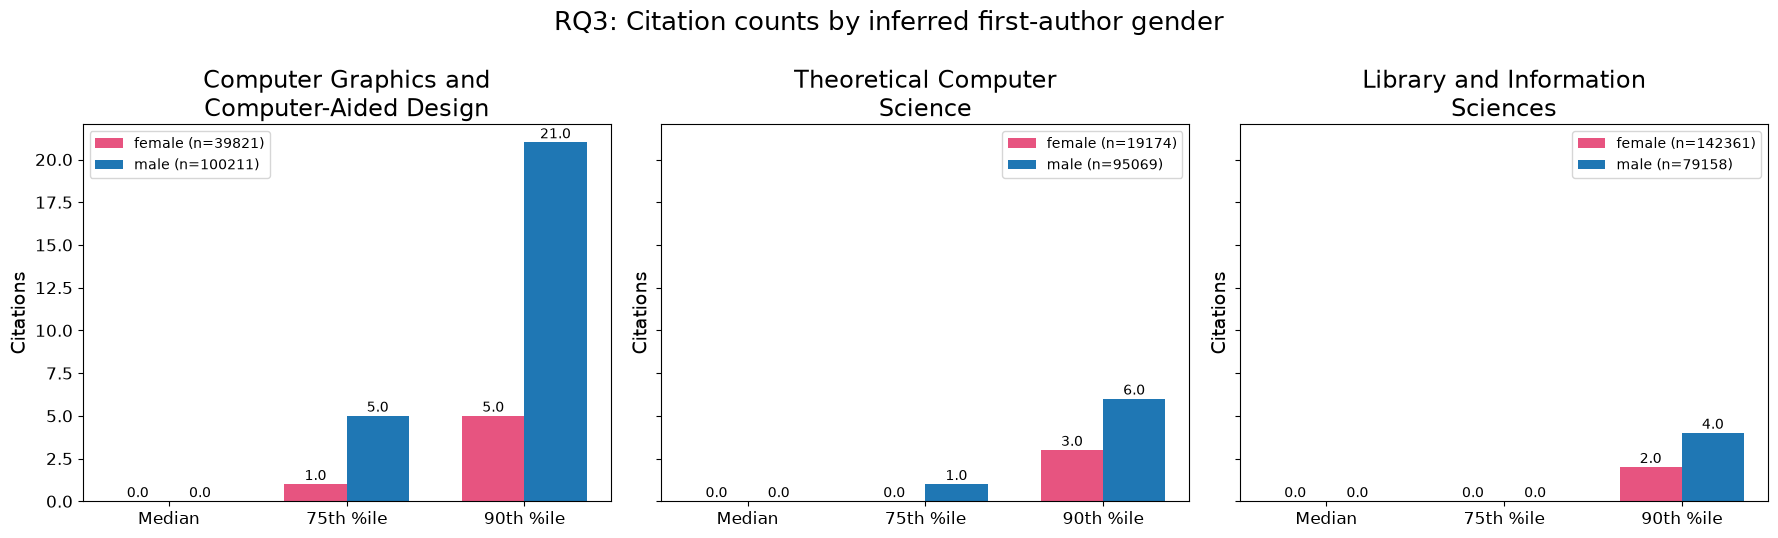

In [110]:
def citation_percentile_bars(ax, f, m, ylabel):
    """Grouped bar chart of median / 75th / 90th percentile, with the
    actual value labeled on each bar. Skewed citation-count data doesn't
    have a great single "shape" plot -- a boxplot's fliers bury everything
    under thousands of outlier dots, and a violin's KDE smooths over the
    sharp zero-inflated spike real citation data has. Percentiles in their
    original units, read directly off the chart, avoid both problems and
    don't need a log transform to stay legible.
    """
    metrics = [("Median", 0.50), ("75th %ile", 0.75), ("90th %ile", 0.90)]
    f_vals = [f.quantile(q) for _, q in metrics]
    m_vals = [m.quantile(q) for _, q in metrics]

    x = np.arange(len(metrics))
    width = 0.35
    bars_f = ax.bar(x - width / 2, f_vals, width, color=GENDER_COLORS["female"], label=f"female (n={len(f)})")
    bars_m = ax.bar(x + width / 2, m_vals, width, color=GENDER_COLORS["male"], label=f"male (n={len(m)})")

    for bars in (bars_f, bars_m):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}", (bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels([label for label, _ in metrics])
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)

corpus_names = list(rq3_df["corpus_name"].unique())
fig, axes = plt.subplots(
    1,
    len(corpus_names),
    figsize=(6 * len(corpus_names), 5.5),
    sharey=True
)

if len(corpus_names) == 1:
    axes = [axes]

for ax, corpus_name in zip(axes, corpus_names):
    g = rq3_df[rq3_df["corpus_name"] == corpus_name]

    f = g.loc[g["first_author_gender_inferred"] == "female", "cited_by_count"]
    m = g.loc[g["first_author_gender_inferred"] == "male", "cited_by_count"]

    citation_percentile_bars(ax, f, m, "Citations")
    ax.set_title(wrap_text(corpus_name, 26))

fig.suptitle(wrap_text("RQ3: Citation counts by inferred first-author gender", 70))
plt.tight_layout()
plt.show()

FWCI (field-weighted citation impact) normalizes for publication year and field (1.0 = field average), correcting for the fact that raw citation counts keep accumulating for as long as a paper has existed.

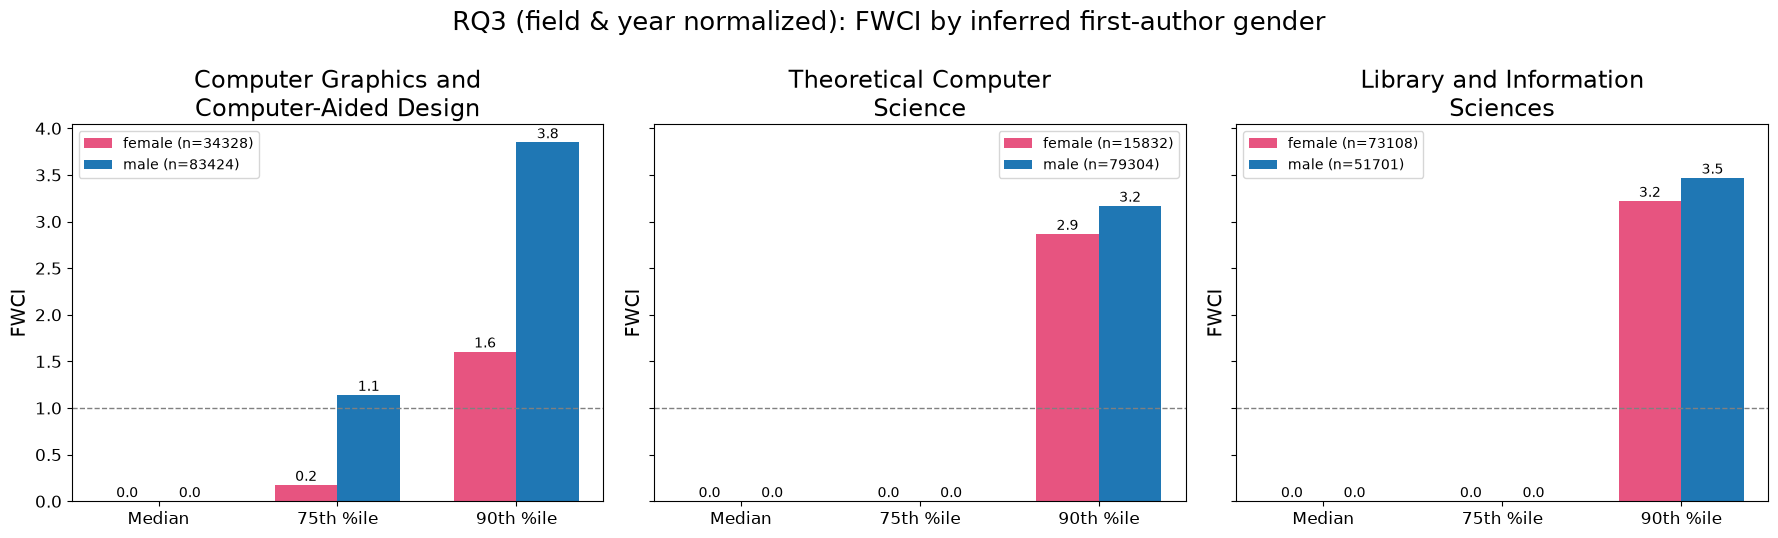

,corpus_name,n_female_first,n_male_first,median_fwci_female_first,median_fwci_male_first,mann_whitney_U,p_value
0,Computer Graphics and Computer-Aided Design,34328,83424,0.0,0.0,1.170287e+09,0.000000
1,Library and Information Sciences,73108,51701,0.0,0.0,1.881007e+09,0.038174
2,Theoretical Computer Science,15832,79304,0.0,0.0,6.210621e+08,0.000381


In [111]:
rq3_fwci_df = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female","male"])
    & papers_df["fwci"].notna()
].copy()

fig, axes = plt.subplots(
    1,
    len(corpus_names),
    figsize=(6 * len(corpus_names), 5.5),
    sharey=True
)

if len(corpus_names) == 1:
    axes = [axes]

for ax, corpus_name in zip(axes, corpus_names):
    g = rq3_fwci_df[rq3_fwci_df["corpus_name"] == corpus_name]

    f = g.loc[g["first_author_gender_inferred"] == "female", "fwci"]
    m = g.loc[g["first_author_gender_inferred"] == "male", "fwci"]

    citation_percentile_bars(ax, f, m, "FWCI")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(wrap_text(corpus_name, 26))

fig.suptitle(wrap_text("RQ3 (field & year normalized): FWCI by inferred first-author gender", 70))
plt.tight_layout()
plt.show()

rq3_fwci_mw = []
for corpus_name, g in rq3_fwci_df.groupby("corpus_name"):
    female = g.loc[g["first_author_gender_inferred"] == "female", "fwci"].dropna()
    male = g.loc[g["first_author_gender_inferred"] == "male", "fwci"].dropna()
    if len(female) and len(male):
        u, p = stats.mannwhitneyu(female, male, alternative="two-sided", method="auto")
    else:
        u, p = np.nan, np.nan
    rq3_fwci_mw.append({
        "corpus_name": corpus_name,
        "n_female_first": len(female), "n_male_first": len(male),
        "median_fwci_female_first": female.median() if len(female) else np.nan,
        "median_fwci_male_first": male.median() if len(male) else np.nan,
        "mann_whitney_U": u, "p_value": p,
    })
display(pd.DataFrame(rq3_fwci_mw))

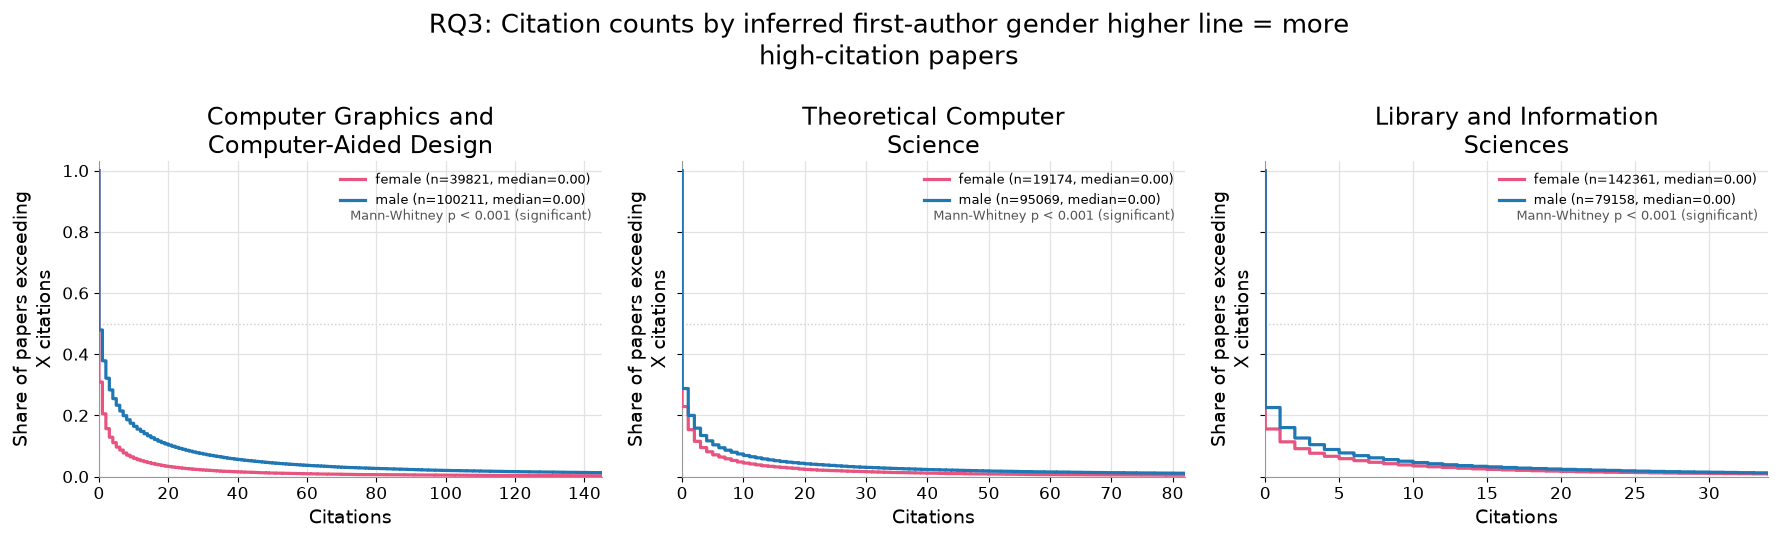

In [112]:
def distribution_line_compare(ax, f, m, xlabel, stats_row=None, x_max_percentile=99, ref_line=None):
    """Survival-curve comparison: one line per gender showing what share of
    papers exceed a given value. Higher on the chart = more high-impact
    papers, which reads the intuitive way (unlike a plain cumulative-share
    curve, where the higher line is actually the *worse*-performing group --
    more of their papers are stuck at low values). Still shows the whole
    distribution shape in one line each, instead of collapsing a skewed,
    zero-inflated distribution into 3 percentile bars.
    """
    def survival(vals):
        v = np.sort(vals.dropna().values)
        if len(v) == 0:
            return v, v
        cum_share = np.arange(1, len(v) + 1) / len(v)
        return v, 1 - cum_share

    fx, fy = survival(f)
    mx, my = survival(m)
    f_med = np.median(f.dropna()) if len(f) else np.nan
    m_med = np.median(m.dropna()) if len(m) else np.nan

    ax.step(fx, fy, where="post", color=GENDER_COLORS["female"], linewidth=2.3, zorder=3,
            label=f"female (n={len(f)}, median={f_med:.2f})")
    ax.step(mx, my, where="post", color=GENDER_COLORS["male"], linewidth=2.3, zorder=3,
            label=f"male (n={len(m)}, median={m_med:.2f})")

    pooled = np.concatenate([f.dropna().values, m.dropna().values]) if (len(f) or len(m)) else np.array([1.0])
    x_cap = np.percentile(pooled, x_max_percentile) if len(pooled) else 1.0
    ax.set_xlim(0, max(x_cap, 0.01))
    ax.set_ylim(0, 1.03)
    ax.axhline(0.5, color="#cccccc", linestyle=":", linewidth=1, zorder=0)
    if ref_line is not None:
        ax.axvline(ref_line, color="#999999", linestyle="--", linewidth=1, zorder=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Share of papers exceeding\nX {xlabel.lower()}")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    style_axis(ax, grid_axis="both")

    if stats_row is not None and pd.notna(stats_row.get("p_value")):
        p = stats_row["p_value"]
        p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        sig = "significant" if p < 0.05 else "n.s."
        ax.text(0.98, 0.85, f"Mann-Whitney {p_text} ({sig})",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#555555")


corpus_names = list(rq3_df["corpus_name"].unique())
mw_lookup = rq3_mw.set_index("corpus_name").to_dict(orient="index")

fig, axes = plt.subplots(
    1,
    len(corpus_names),
    figsize=(6 * len(corpus_names), 5.5),
    sharey=True
)

if len(corpus_names) == 1:
    axes = [axes]

for ax, corpus_name in zip(axes, corpus_names):
    g = rq3_df[rq3_df["corpus_name"] == corpus_name]

    f = g.loc[g["first_author_gender_inferred"] == "female", "cited_by_count"]
    m = g.loc[g["first_author_gender_inferred"] == "male", "cited_by_count"]

    distribution_line_compare(ax, f, m, "Citations", stats_row=mw_lookup.get(corpus_name))
    ax.set_title(wrap_text(corpus_name, 26))

fig.suptitle(wrap_text("RQ3: Citation counts by inferred first-author gender higher line = more high-citation papers", 75))
plt.tight_layout()
plt.show()

# Representation & inequality (Jaramillo et al. 2025 method)

Two additional metrics, adapted from Jaramillo, Macedo, Oliveira, Karimi & Menezes (2025), *Systematic comparison of gender inequality in scientific rankings across disciplines*:

- **Representation ratio**: for the top-x% of researchers by citations, the ratio of women's share in that top slice to their overall share in the field. 1.0 = fair representation.
- **Gini coefficient**: inequality of the citation distribution per corpus.

Both use the author-level table built above.

In [113]:
def gini(values):
    """Standard Gini coefficient (0 = perfectly equal, 1 = maximally unequal)."""
    x = np.sort(np.asarray(values, dtype=float))
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * x)) / (n * np.sum(x)) - (n + 1) / n

gini_summary = (
    author_level_df
    .groupby("corpus_name")["total_citations"]
    .apply(gini)
    .rename("citation_gini")
    .reset_index()
)
display(gini_summary)

,corpus_name,citation_gini
0,Computer Graphics and Computer-Aided Design,0.944805
1,Library and Information Sciences,0.913986
2,Theoretical Computer Science,0.961841


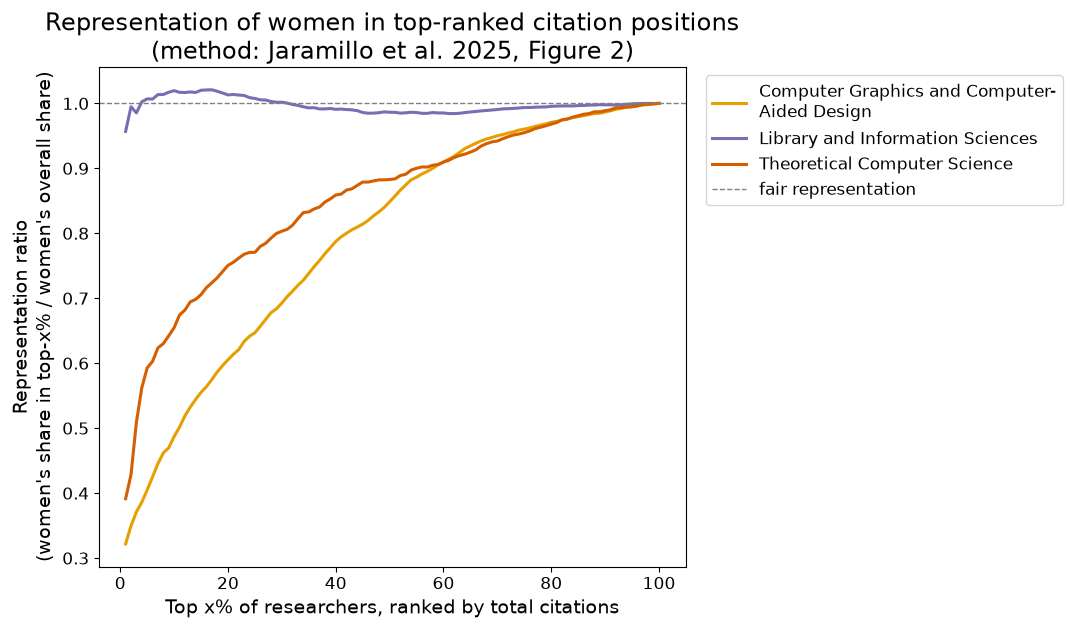

In [114]:
def representation_curve(df_corpus, gender_col="gender_inferred",
                          value_col="total_citations", target="female",
                          percentiles=None):
    """Representation ratio of `target` gender in the top-x% by `value_col`,
    relative to that gender's participation across the whole (binary-known)
    corpus population. Mirrors Figure 2 (left) of Jaramillo et al. 2025.
    """
    if percentiles is None:
        percentiles = np.arange(1, 101)

    d = df_corpus[df_corpus[gender_col].isin(["female", "male"])].copy()
    d = d.sort_values(value_col, ascending=False).reset_index(drop=True)
    n = len(d)
    participation = (d[gender_col] == target).mean() if n else np.nan

    ratios = []
    for p in percentiles:
        k = max(1, int(np.ceil(n * p / 100)))
        top = d.iloc[:k]
        prop_top = (top[gender_col] == target).mean()
        ratios.append(prop_top / participation if participation else np.nan)

    return pd.DataFrame({"percentile": percentiles, "representation_ratio": ratios})

fig, ax = plt.subplots(figsize=(11, 6.5))
for corpus_name, g in author_level_df.groupby("corpus_name"):
    curve = representation_curve(g)
    ax.plot(curve["percentile"], curve["representation_ratio"],
            color=CORPUS_COLORS.get(corpus_name), linewidth=2.2,
            label=wrap_text(corpus_name, 32))

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="fair representation")
ax.set_xlabel("Top x% of researchers, ranked by total citations")
ax.set_ylabel("Representation ratio\n(women's share in top-x% / women's overall share)")
ax.set_title(wrap_text("Representation of women in top-ranked citation positions (method: Jaramillo et al. 2025, Figure 2)", 60))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# RQ4: Author gender over time

Each year's female/male first-authored paper count is expressed as a share of that year's total (`share_of_year`), since raw counts aren't comparable across years or corpora of different sizes.

Publication years below `MIN_PLAUSIBLE_YEAR` are excluded from these plots as likely metadata errors, with a printed diagnostic of exactly what was dropped.

In [115]:
MIN_PLAUSIBLE_YEAR = 1950  # adjust if your fields genuinely have earlier legitimate papers

implausible = papers_df[
    papers_df["publication_year"].notna()
    & (papers_df["publication_year"] < MIN_PLAUSIBLE_YEAR)
]
if len(implausible):
    print(f"Excluding {len(implausible)} papers with publication_year < {MIN_PLAUSIBLE_YEAR} "
          f"from year-based trend plots (kept everywhere else in this notebook):")
    print("  excluded year range:", int(implausible['publication_year'].min()),
          "-", int(implausible['publication_year'].max()))
    print("  by corpus:", implausible["corpus_name"].value_counts().to_dict())
else:
    print(f"No papers below MIN_PLAUSIBLE_YEAR={MIN_PLAUSIBLE_YEAR} -- nothing excluded.")

citation_time_df = papers_df[
    papers_df["first_author_gender_inferred"].isin(["female", "male"])
    & papers_df["publication_year"].notna()
    & (papers_df["publication_year"] >= MIN_PLAUSIBLE_YEAR)
    & papers_df["cited_by_count"].notna()
].copy()

citation_time_df["publication_year"] = (
    citation_time_df["publication_year"].astype(int)
)

citation_time_df["decade"] = (
    citation_time_df["publication_year"] // 10 * 10
)

citation_time_df["decade_label"] = (
    citation_time_df["decade"].astype(str) + "s"
)

year_totals = (
    citation_time_df
    .groupby(["corpus_name", "publication_year"])
    .size()
    .rename("n_year_total")
)

year_gender_citations = (
    citation_time_df
    .groupby([
        "corpus_name",
        "publication_year",
        "first_author_gender_inferred"
    ])
    .agg(
        n_papers=("work_id", "size"),
        total_citations=("cited_by_count", "sum"),
        mean_citations=("cited_by_count", "mean"),
        median_citations=("cited_by_count", "median"),
        std_citations=("cited_by_count", "std"),
        mean_fwci=("fwci", "mean"),
    )
    .reset_index()
    .merge(year_totals, on=["corpus_name", "publication_year"])
    .sort_values(["corpus_name", "publication_year", "first_author_gender_inferred"])
)

# the actual normalized-frequency column RQ5 needs: this year's
# female/male first-authored papers as a share of ALL first-authored
# papers that corpus published that year, not a raw count
year_gender_citations["share_of_year"] = (
    year_gender_citations["n_papers"] / year_gender_citations["n_year_total"]
)

display(year_gender_citations)

Excluding 50550 papers with publication_year < 1950 from year-based trend plots (kept everywhere else in this notebook):
  excluded year range: 1400 - 1949
  by corpus: {'Theoretical Computer Science': 38812, 'Library and Information Sciences': 9647, 'Computer Graphics and Computer-Aided Design': 2091}


,corpus_name,publication_year,first_author_gender_inferred,n_papers,total_citations,mean_citations,median_citations,std_citations,mean_fwci,n_year_total,share_of_year
0,Computer Graphics and Computer-Aided Design,1950,female,5,0,0.000000,0.0,0.000000,0.000000,46,0.108696
1,Computer Graphics and Computer-Aided Design,1950,male,41,440,10.731707,0.0,47.081857,1.523350,46,0.891304
2,Computer Graphics and Computer-Aided Design,1951,female,6,107,17.833333,0.0,43.194521,0.000000,27,0.222222
3,Computer Graphics and Computer-Aided Design,1951,male,21,1372,65.333333,1.0,281.875209,0.996300,27,0.777778
4,Computer Graphics and Computer-Aided Design,1952,female,1,0,0.000000,0.0,NaN,0.000000,38,0.026316
...,...,...,...,...,...,...,...,...,...,...,...
457,Theoretical Computer Science,2024,male,1758,737,0.419226,0.0,2.559039,1.754277,2301,0.764016
458,Theoretical Computer Science,2025,female,752,105,0.139628,0.0,1.601572,1.718831,3517,0.213819
459,Theoretical Computer Science,2025,male,2765,327,0.118264,0.0,1.669329,1.403659,3517,0.786181
460,Theoretical Computer Science,2026,female,860,9,0.010465,0.0,0.131729,0.234137,5586,0.153956


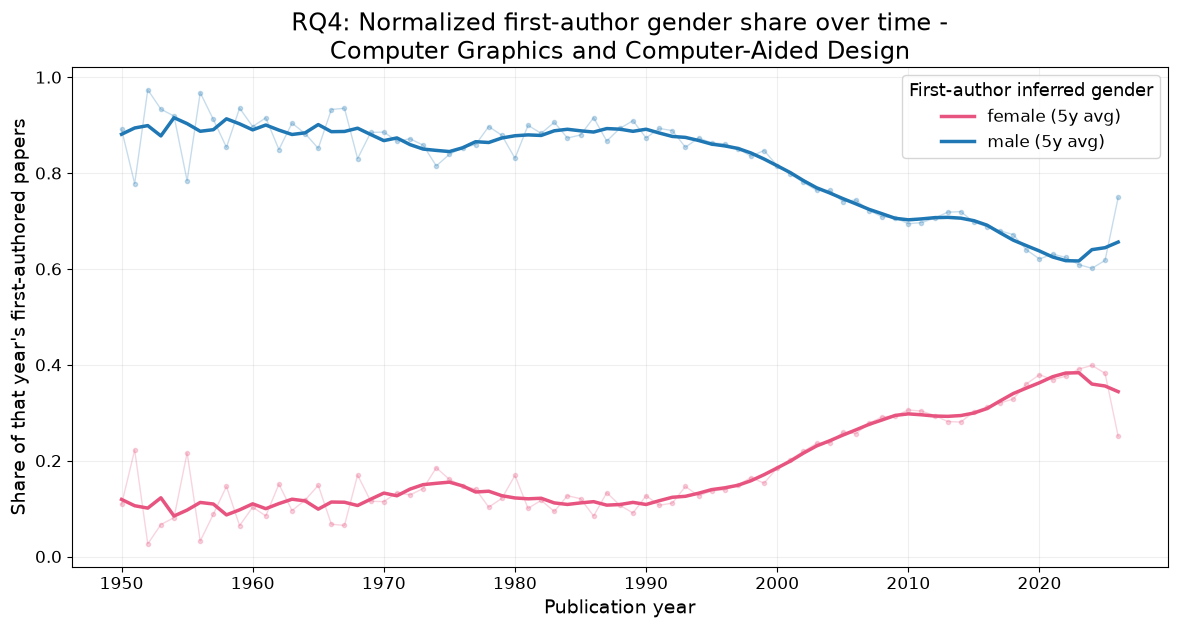

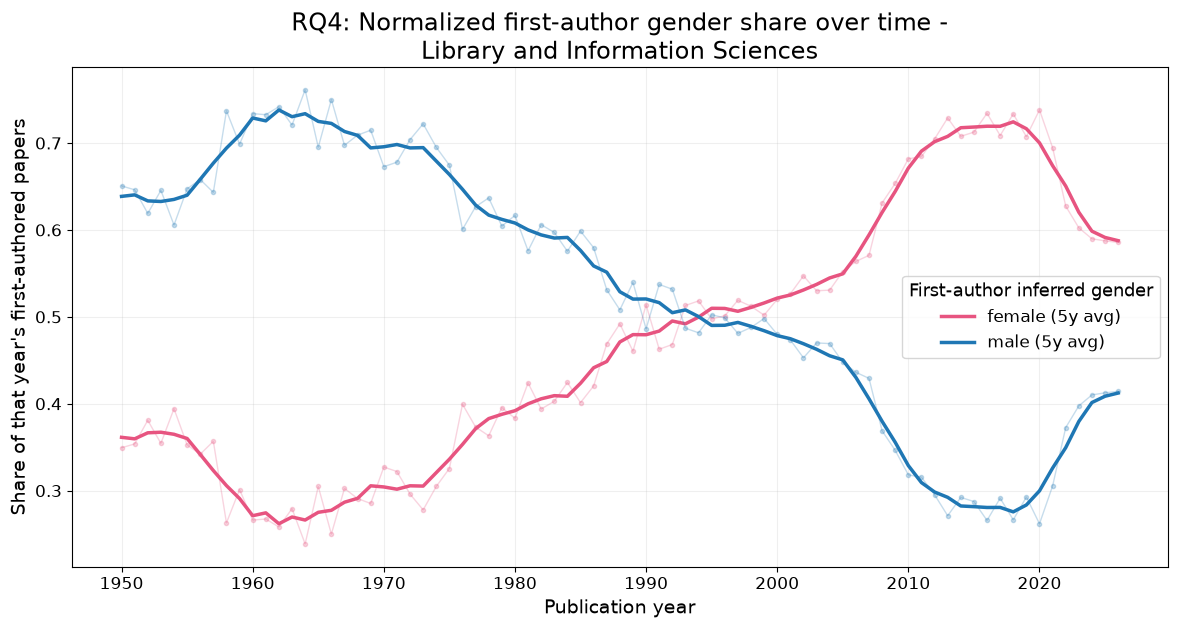

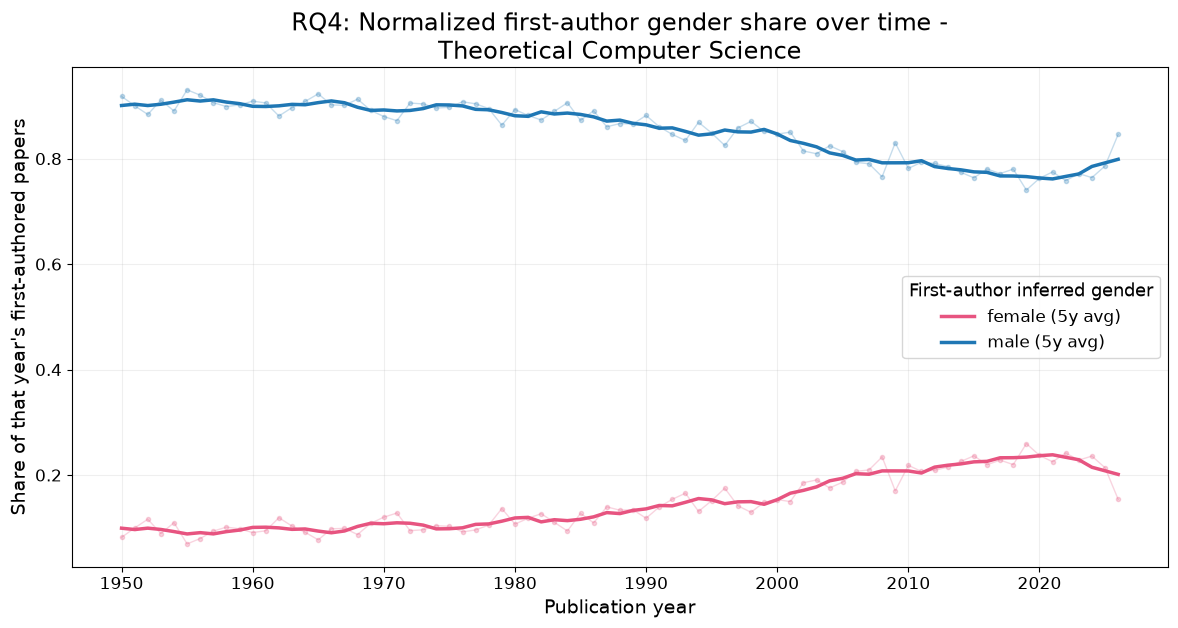

In [116]:
# Plot A: normalized share of female/male first-authored papers per year.
# This is the direct, frequency-normalized answer to RQ5, and is comparable
# across corpora of very different total size because it's a share, not a
# count. A rolling average (reindexed onto every calendar year first, same
# fix as the RQ2/Plot-B cells) is layered on top so the trend is readable
# through the year-to-year noise.
ROLLING_WINDOW_YEARS = 5  # keep in sync with the RQ2/Plot-B cells if you change it there

for corpus_name, g in year_gender_citations.groupby("corpus_name"):

    plt.figure(figsize=(12, 6.5))

    for gender_name, gg in g.groupby("first_author_gender_inferred"):
        gg = gg.sort_values("publication_year")
        full_years, s = reindex_to_full_years(gg, "publication_year", ["share_of_year"])
        s = s["share_of_year"]
        rolling = s.rolling(ROLLING_WINDOW_YEARS, min_periods=1, center=True).mean()

        color = GENDER_COLORS.get(gender_name)
        plt.plot(full_years, s, marker="o", markersize=3, alpha=0.25, linewidth=1, color=color)
        plt.plot(full_years, rolling, linewidth=2.5, color=color,
                 label=f"{gender_name} ({ROLLING_WINDOW_YEARS}y avg)")

    plt.xlabel("Publication year")
    plt.ylabel("Share of that year's first-authored papers")
    plt.title(wrap_text(f"RQ4: Normalized first-author gender share over time - {corpus_name}", 60))
    plt.legend(title="First-author inferred gender")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

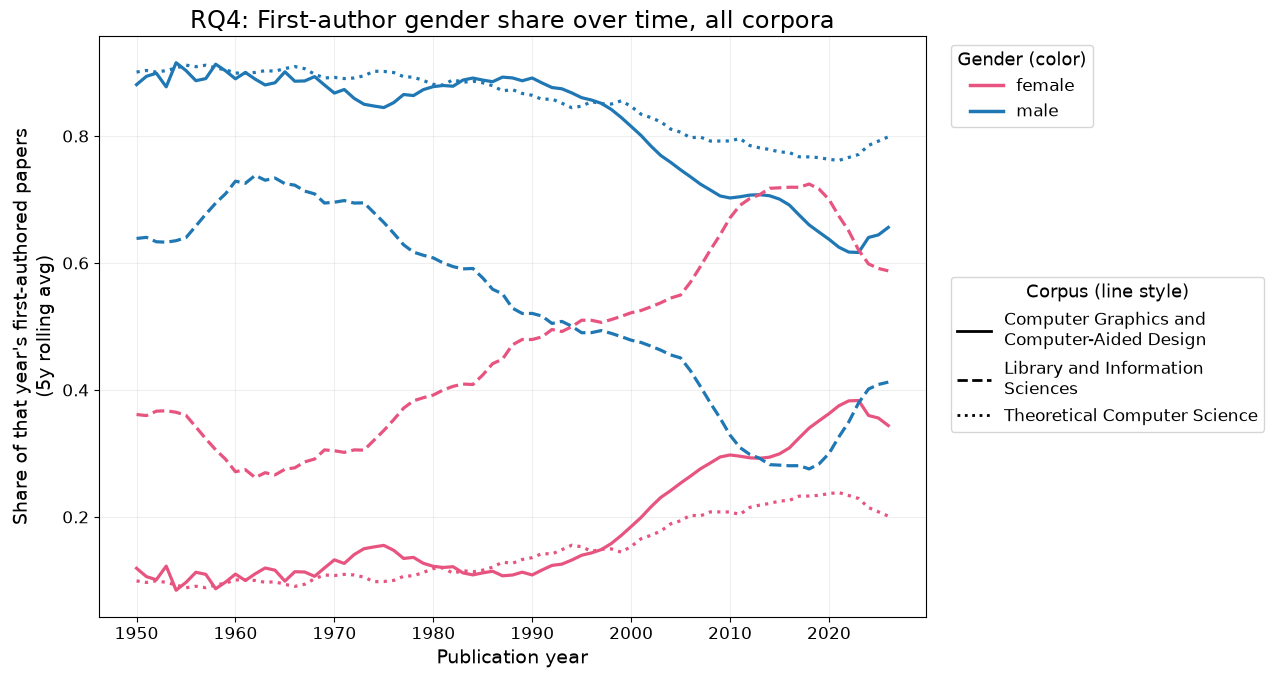

In [117]:

fig, ax = plt.subplots(figsize=(13, 7))

for (corpus_name, gender_name), g in year_gender_citations.groupby(["corpus_name", "first_author_gender_inferred"]):
    g = g.sort_values("publication_year")
    full_years, s = reindex_to_full_years(g, "publication_year", ["share_of_year"])
    rolling = s["share_of_year"].rolling(ROLLING_WINDOW_YEARS, min_periods=1, center=True).mean()
    ax.plot(
        full_years, rolling,
        color=GENDER_COLORS.get(gender_name),
        linestyle=CORPUS_LINESTYLES.get(corpus_name),
        linewidth=2.3
    )

ax.set_xlabel("Publication year")
ax.set_ylabel(f"Share of that year's first-authored papers\n({ROLLING_WINDOW_YEARS}y rolling avg)")
ax.set_title(wrap_text("RQ4: First-author gender share over time, all corpora", 60))
ax.grid(alpha=0.2)

gender_handles = [Line2D([0], [0], color=GENDER_COLORS[g], lw=2.5, label=g) for g in ["female", "male"]]
corpus_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=ls, label=wrap_text(name, 28))
    for name, ls in CORPUS_LINESTYLES.items()
]
legend1 = ax.legend(handles=gender_handles, title="Gender (color)", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(handles=corpus_handles, title="Corpus (line style)", loc="upper left", bbox_to_anchor=(1.02, 0.6))
plt.tight_layout()
plt.show()